# Embedding Visualisation

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from utils import process_rw_file
import numpy as np

from vis import (
    Plotter,
    _window_and_filter,
    load_embeddings_pt,
    centroids_by_token,
)

# ALBERI

## Exp 1: Numbers Tree (shuffled)

  [] Warning: token '1' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '4' has only 8 occurrences in [0:50] (requested 10)
  [] Warning: token '7' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token '12' has only 3 occurrences in [0:500] (requested 10)
  [] Warning: token '2' has only 9 occurrences in [0:500] (requested 10)
  [] Warning: token '5' has only 7 occurrences in [0:500] (requested 10)
  [] Warning: token '6' has only 3 occurrences in [0:500] (requested 10)
  [] Warning: token '9' has only 5 occurrences in [0:500] (requested 10)


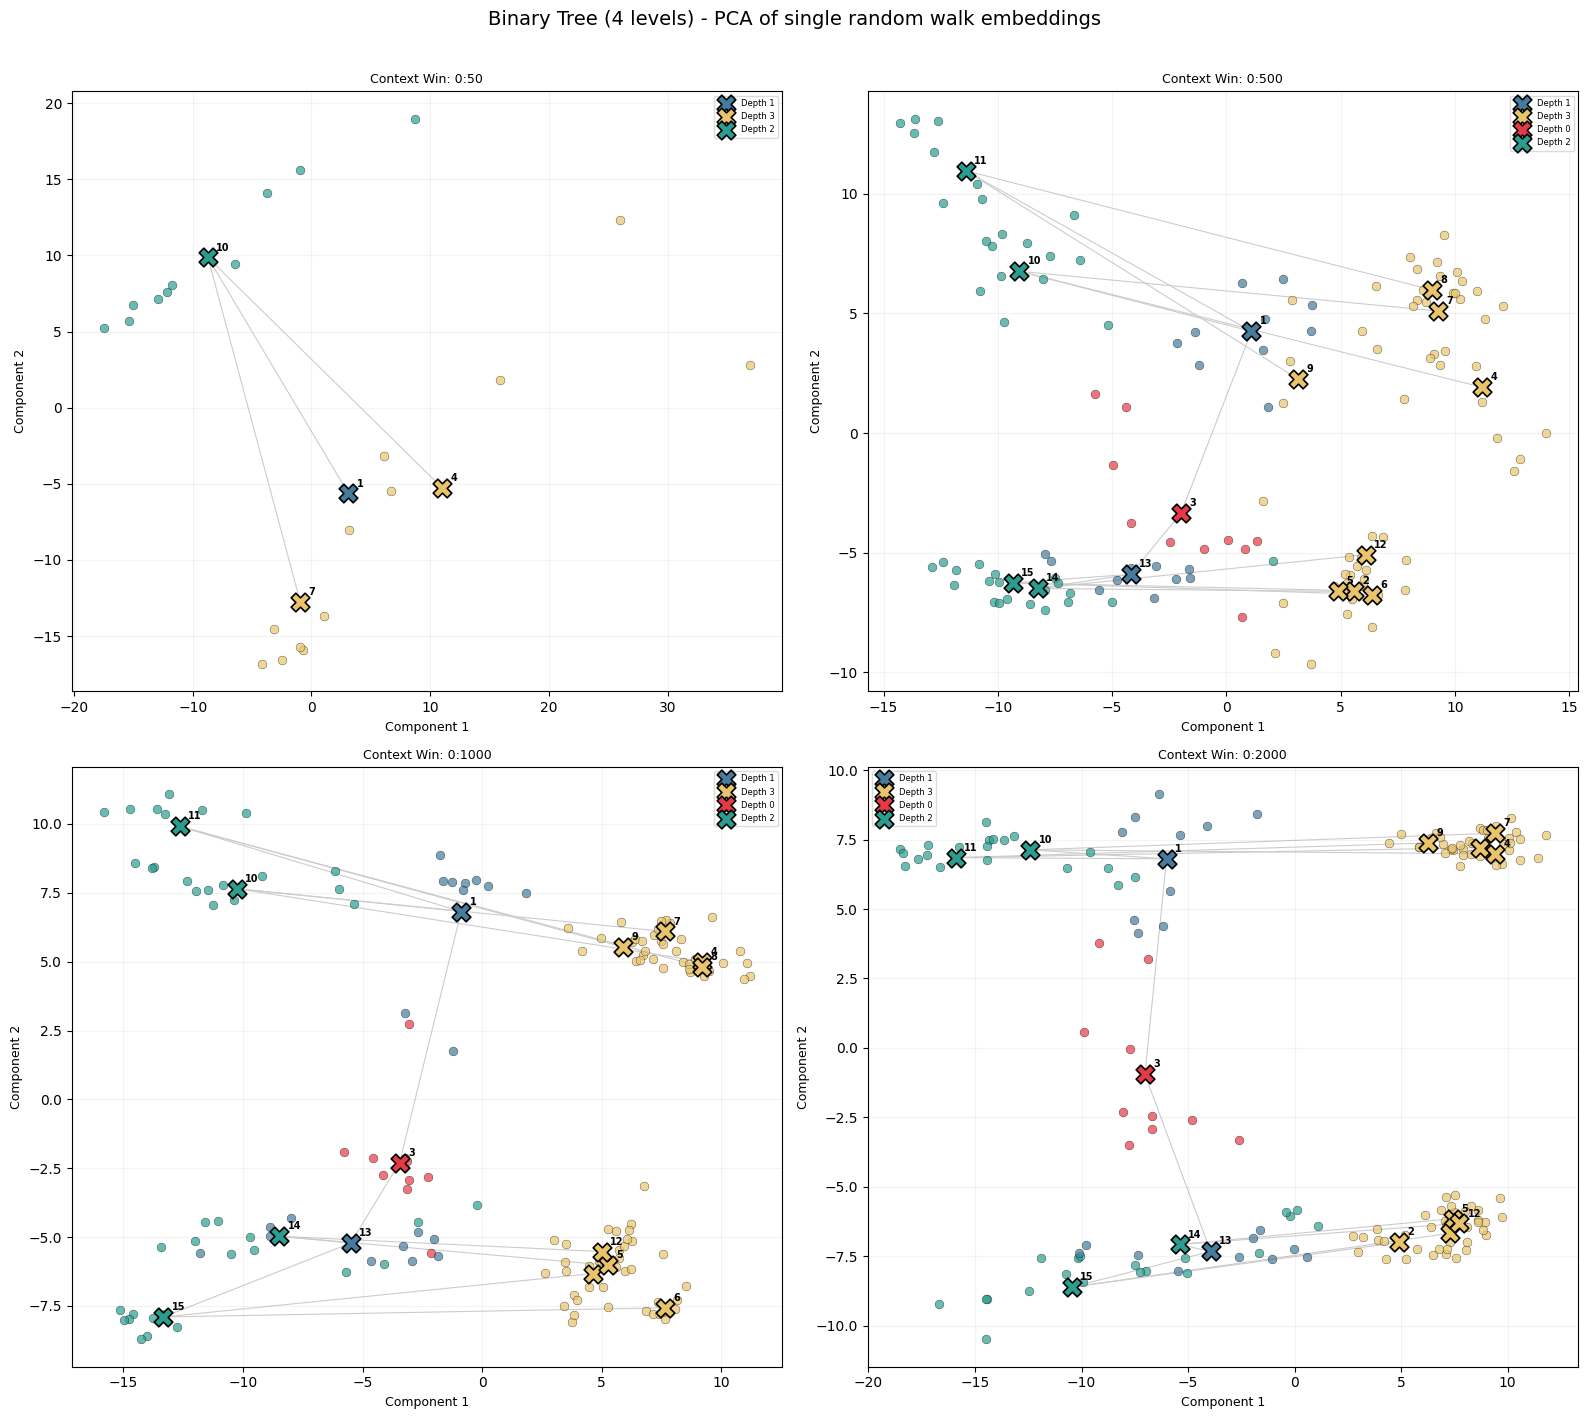

In [ ]:
EMB_DIR     = Path("../embeddings/numbers/shuffled_tree_numbers")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/shuffled_tree_numbers/bin_tree_structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [50,500, 1000, 2000]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_bin_tree_numbers_shuffled_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(filtered_embs)

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle("Binary Tree (4 levels) - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

Processing context length: 50
  [] Warning: token '12' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token '2' has only 7 occurrences in [0:50] (requested 10)
  [] Warning: token '5' has only 7 occurrences in [0:50] (requested 10)
  [] Warning: token '6' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token '8' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '9' has only 1 occurrences in [0:50] (requested 10)
Processing context length: 500
Processing context length: 1000
Processing context length: 2000


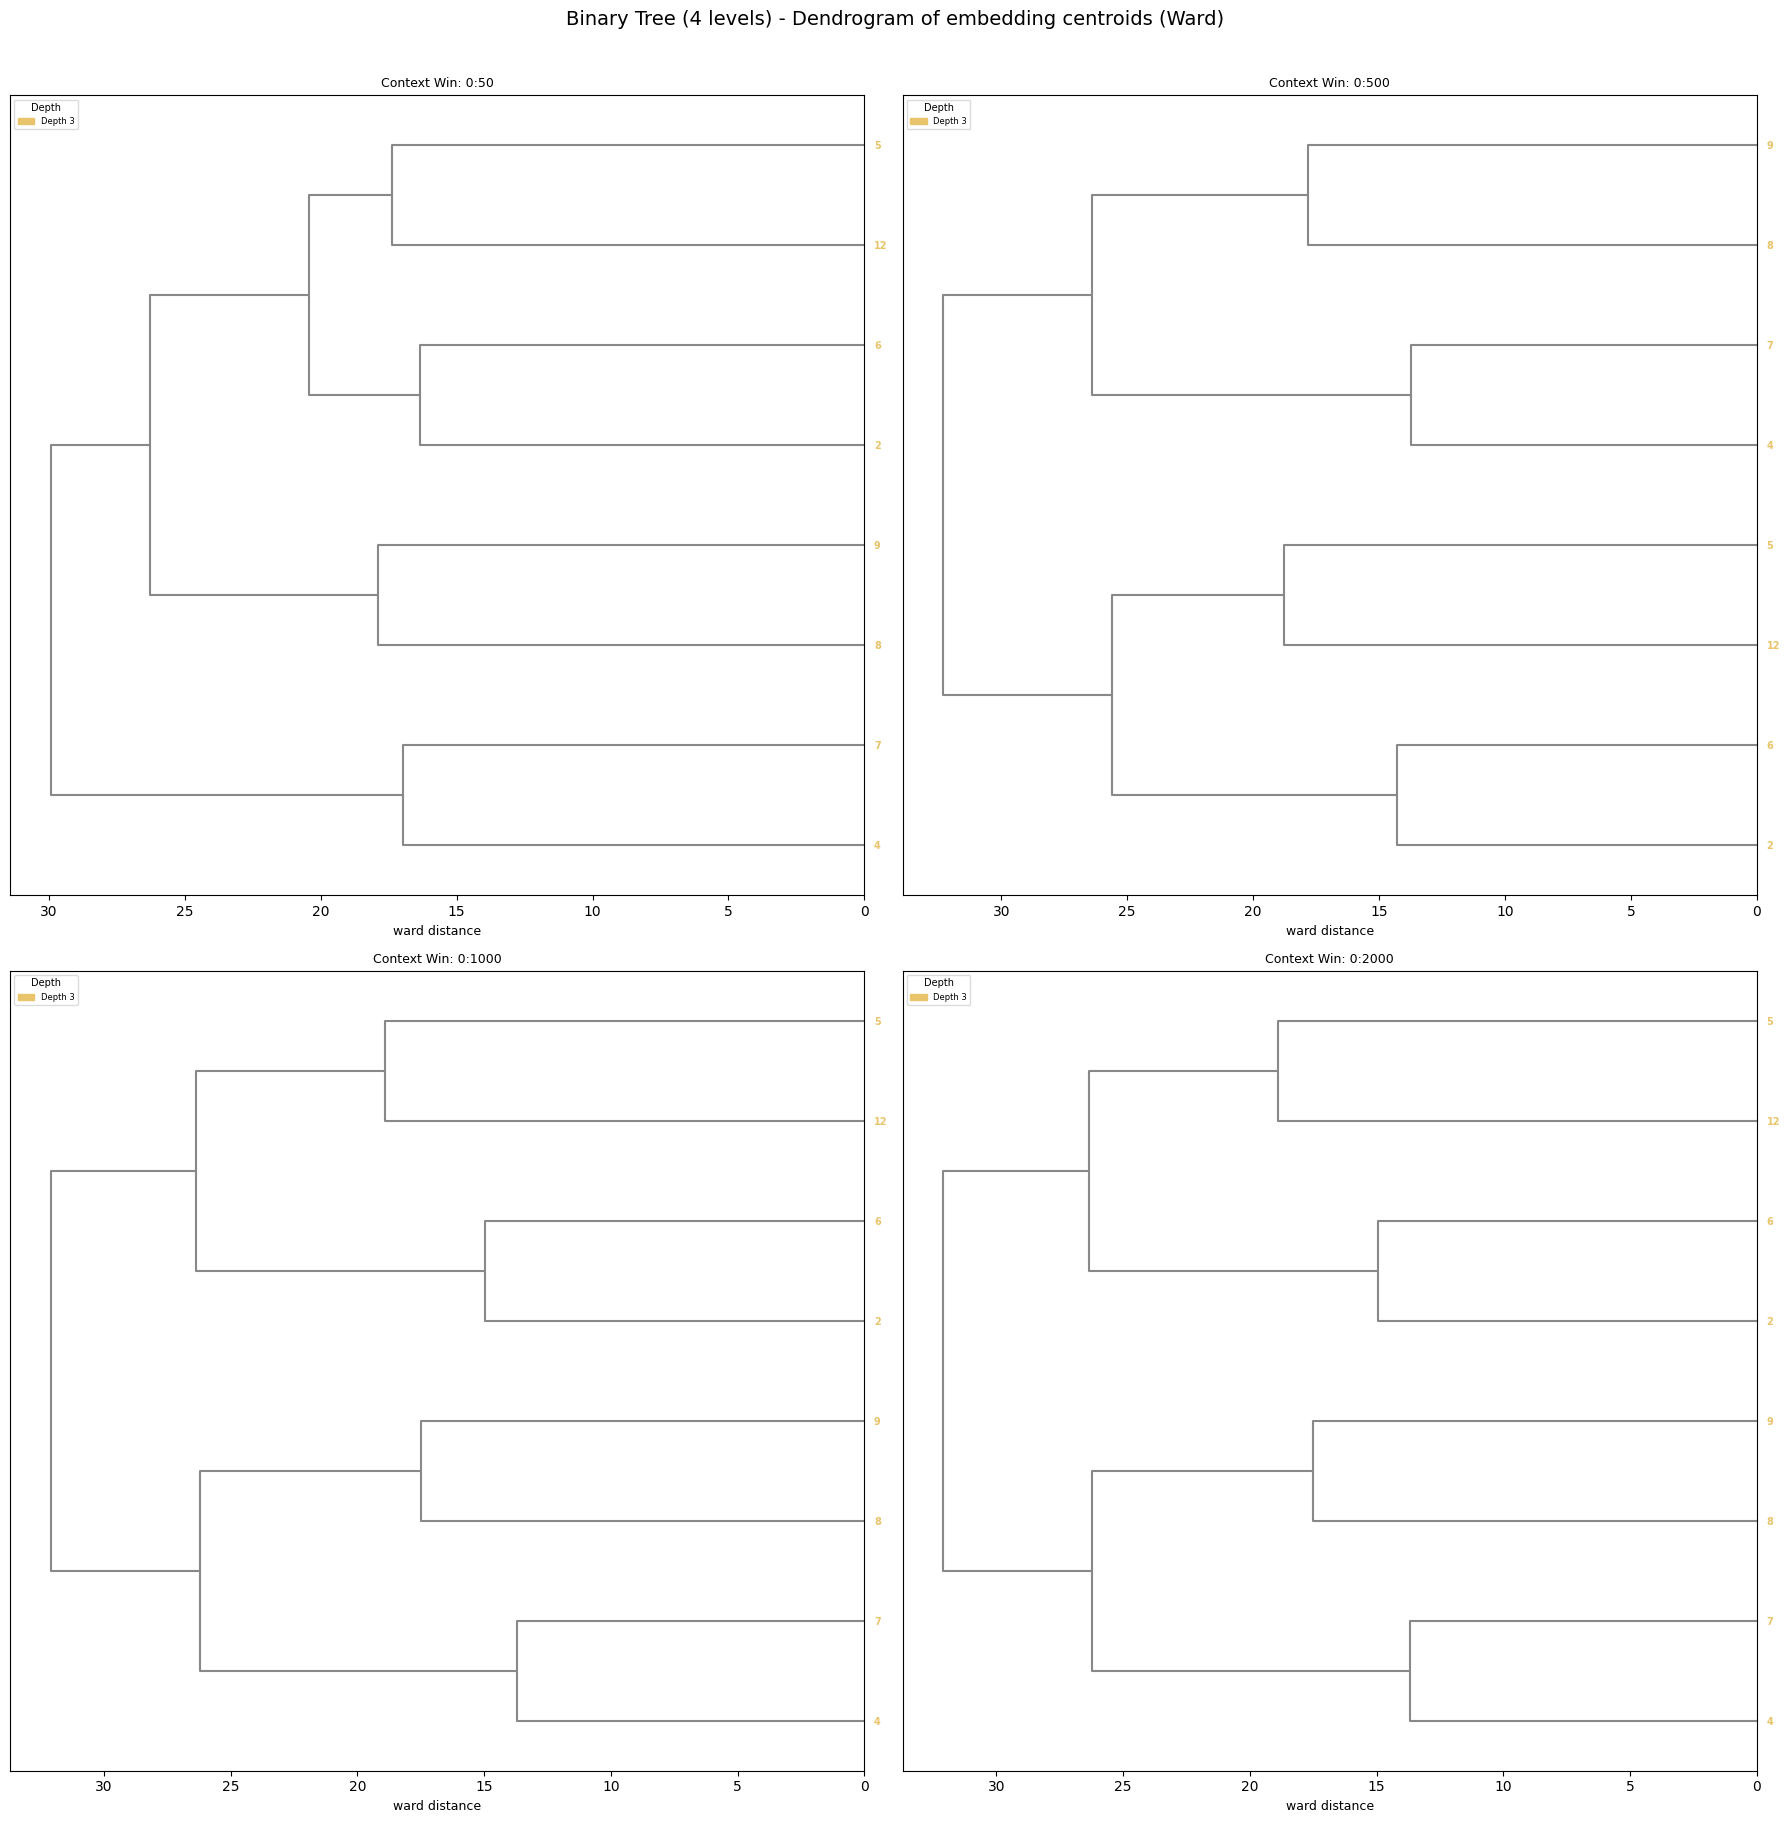

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

layer = 3 # quale livello dell'albero dendrogrammo

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

for ax, win in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {win}")
    pt_path = EMB_DIR / f"reprs_bin_tree_numbers_shuffled_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    mask_layer_l = np.isin(ids_np, ids_layer_l)

    emb_np = emb_np[mask_layer_l]
    ids_np = ids_np[mask_layer_l]

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, k=10, t_end=win)

    centroids_id, centroids_emb = centroids_by_token(filtered_ids, filtered_embs)

    hp_tree.plot_dendrogram_on_points(ax, centroids_id, centroids_emb, title=f"Context Win: 0:{win}", method="ward", max_leaves=50)

fig.suptitle("Binary Tree (4 levels) - Dendrogram of embedding centroids (Ward)",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Exp 2: Numbers Tree (ordered)

  [] Warning: token '15' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token '13' has only 8 occurrences in [0:50] (requested 10)
  [] Warning: token '12' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '1' has only 3 occurrences in [0:500] (requested 10)
  [] Warning: token '3' has only 7 occurrences in [0:500] (requested 10)
  [] Warning: token '5' has only 9 occurrences in [0:500] (requested 10)
  [] Warning: token '7' has only 3 occurrences in [0:500] (requested 10)
  [] Warning: token '9' has only 5 occurrences in [0:500] (requested 10)


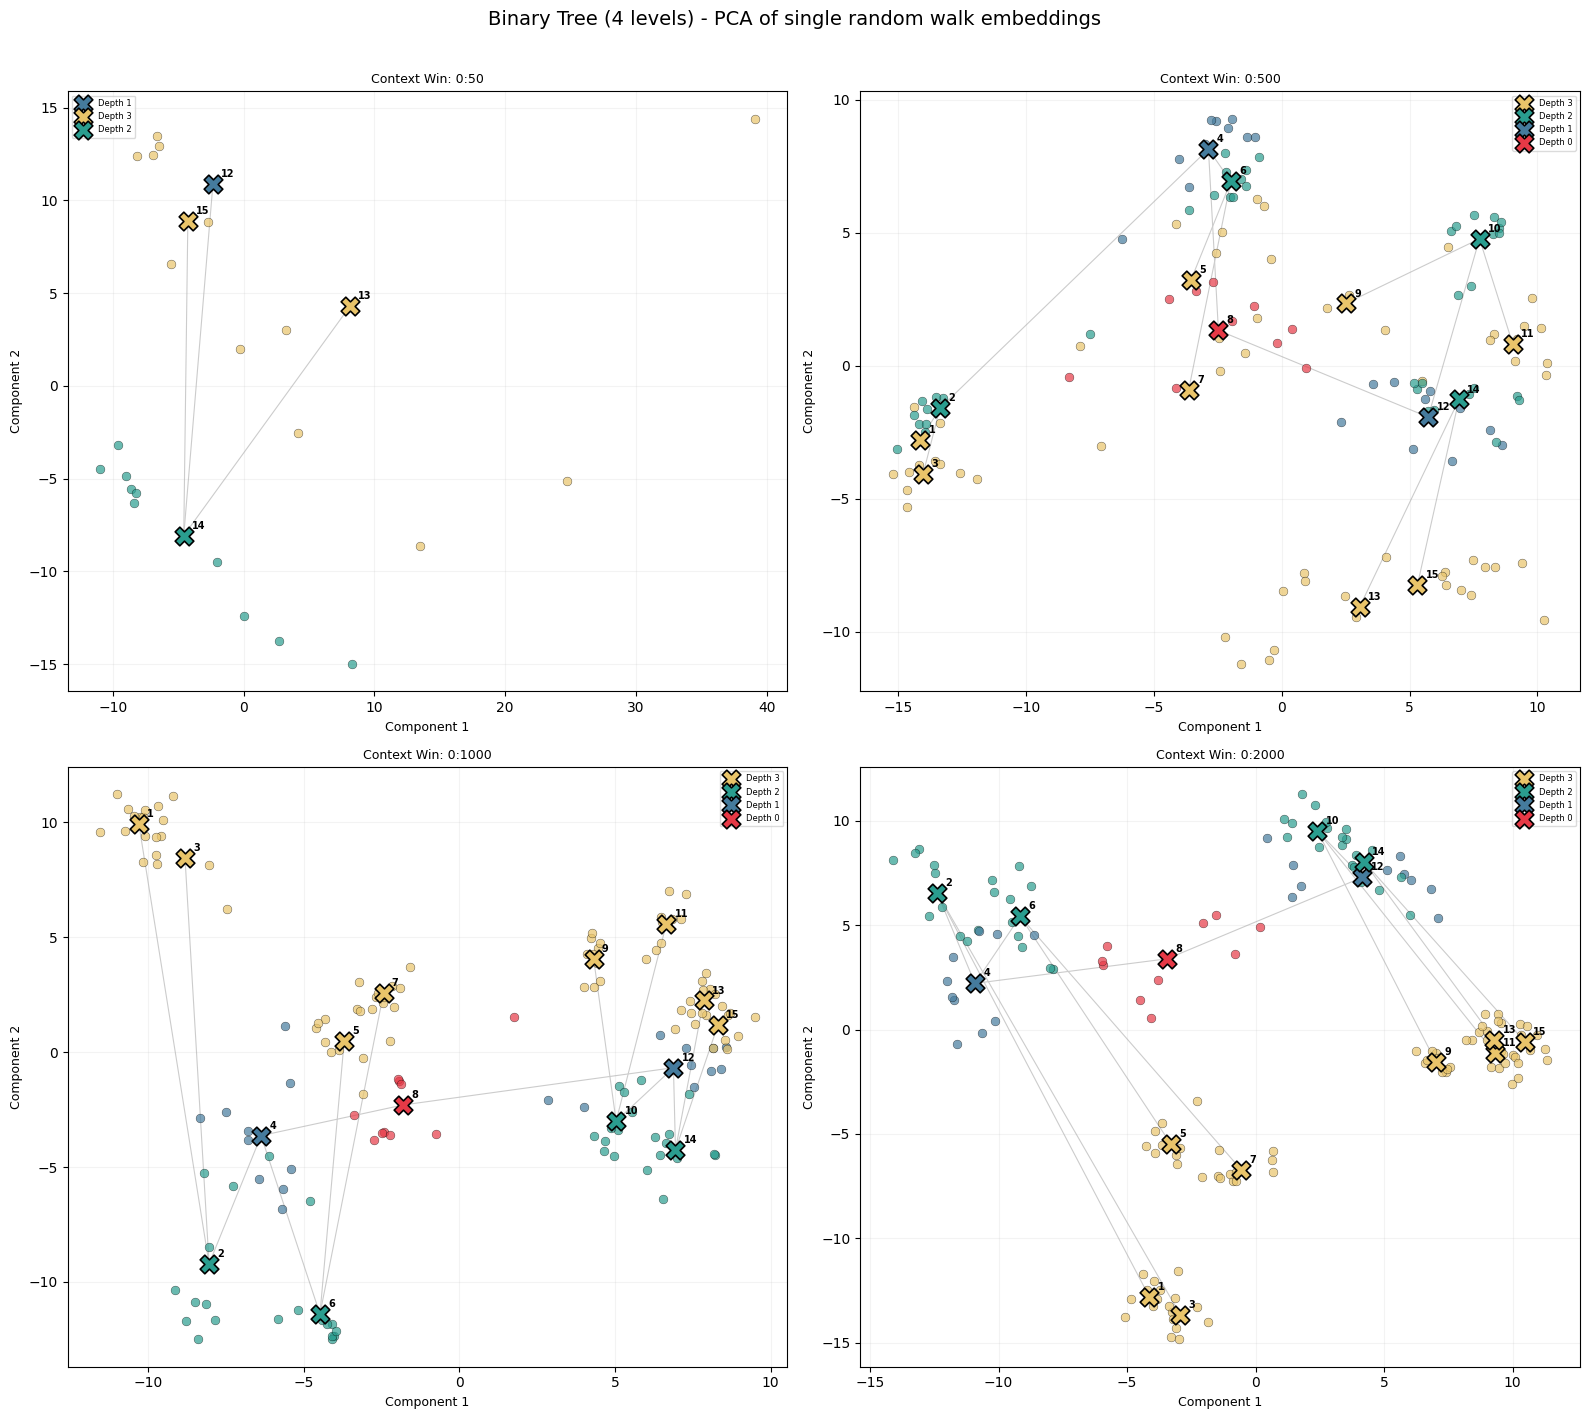

In [17]:
EMB_DIR     = Path("../embeddings/numbers/tree_numbers")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/tree_numbers/bin_tree_structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)


fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [50,500, 1000, 2000]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_bin_tree_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(filtered_embs)

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle("Binary Tree (4 levels) - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

Processing context length: 50
  [] Warning: token '11' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '1' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token '3' has only 7 occurrences in [0:50] (requested 10)
  [] Warning: token '5' has only 7 occurrences in [0:50] (requested 10)
  [] Warning: token '7' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token '9' has only 1 occurrences in [0:50] (requested 10)
Processing context length: 500
Processing context length: 1000
Processing context length: 2000


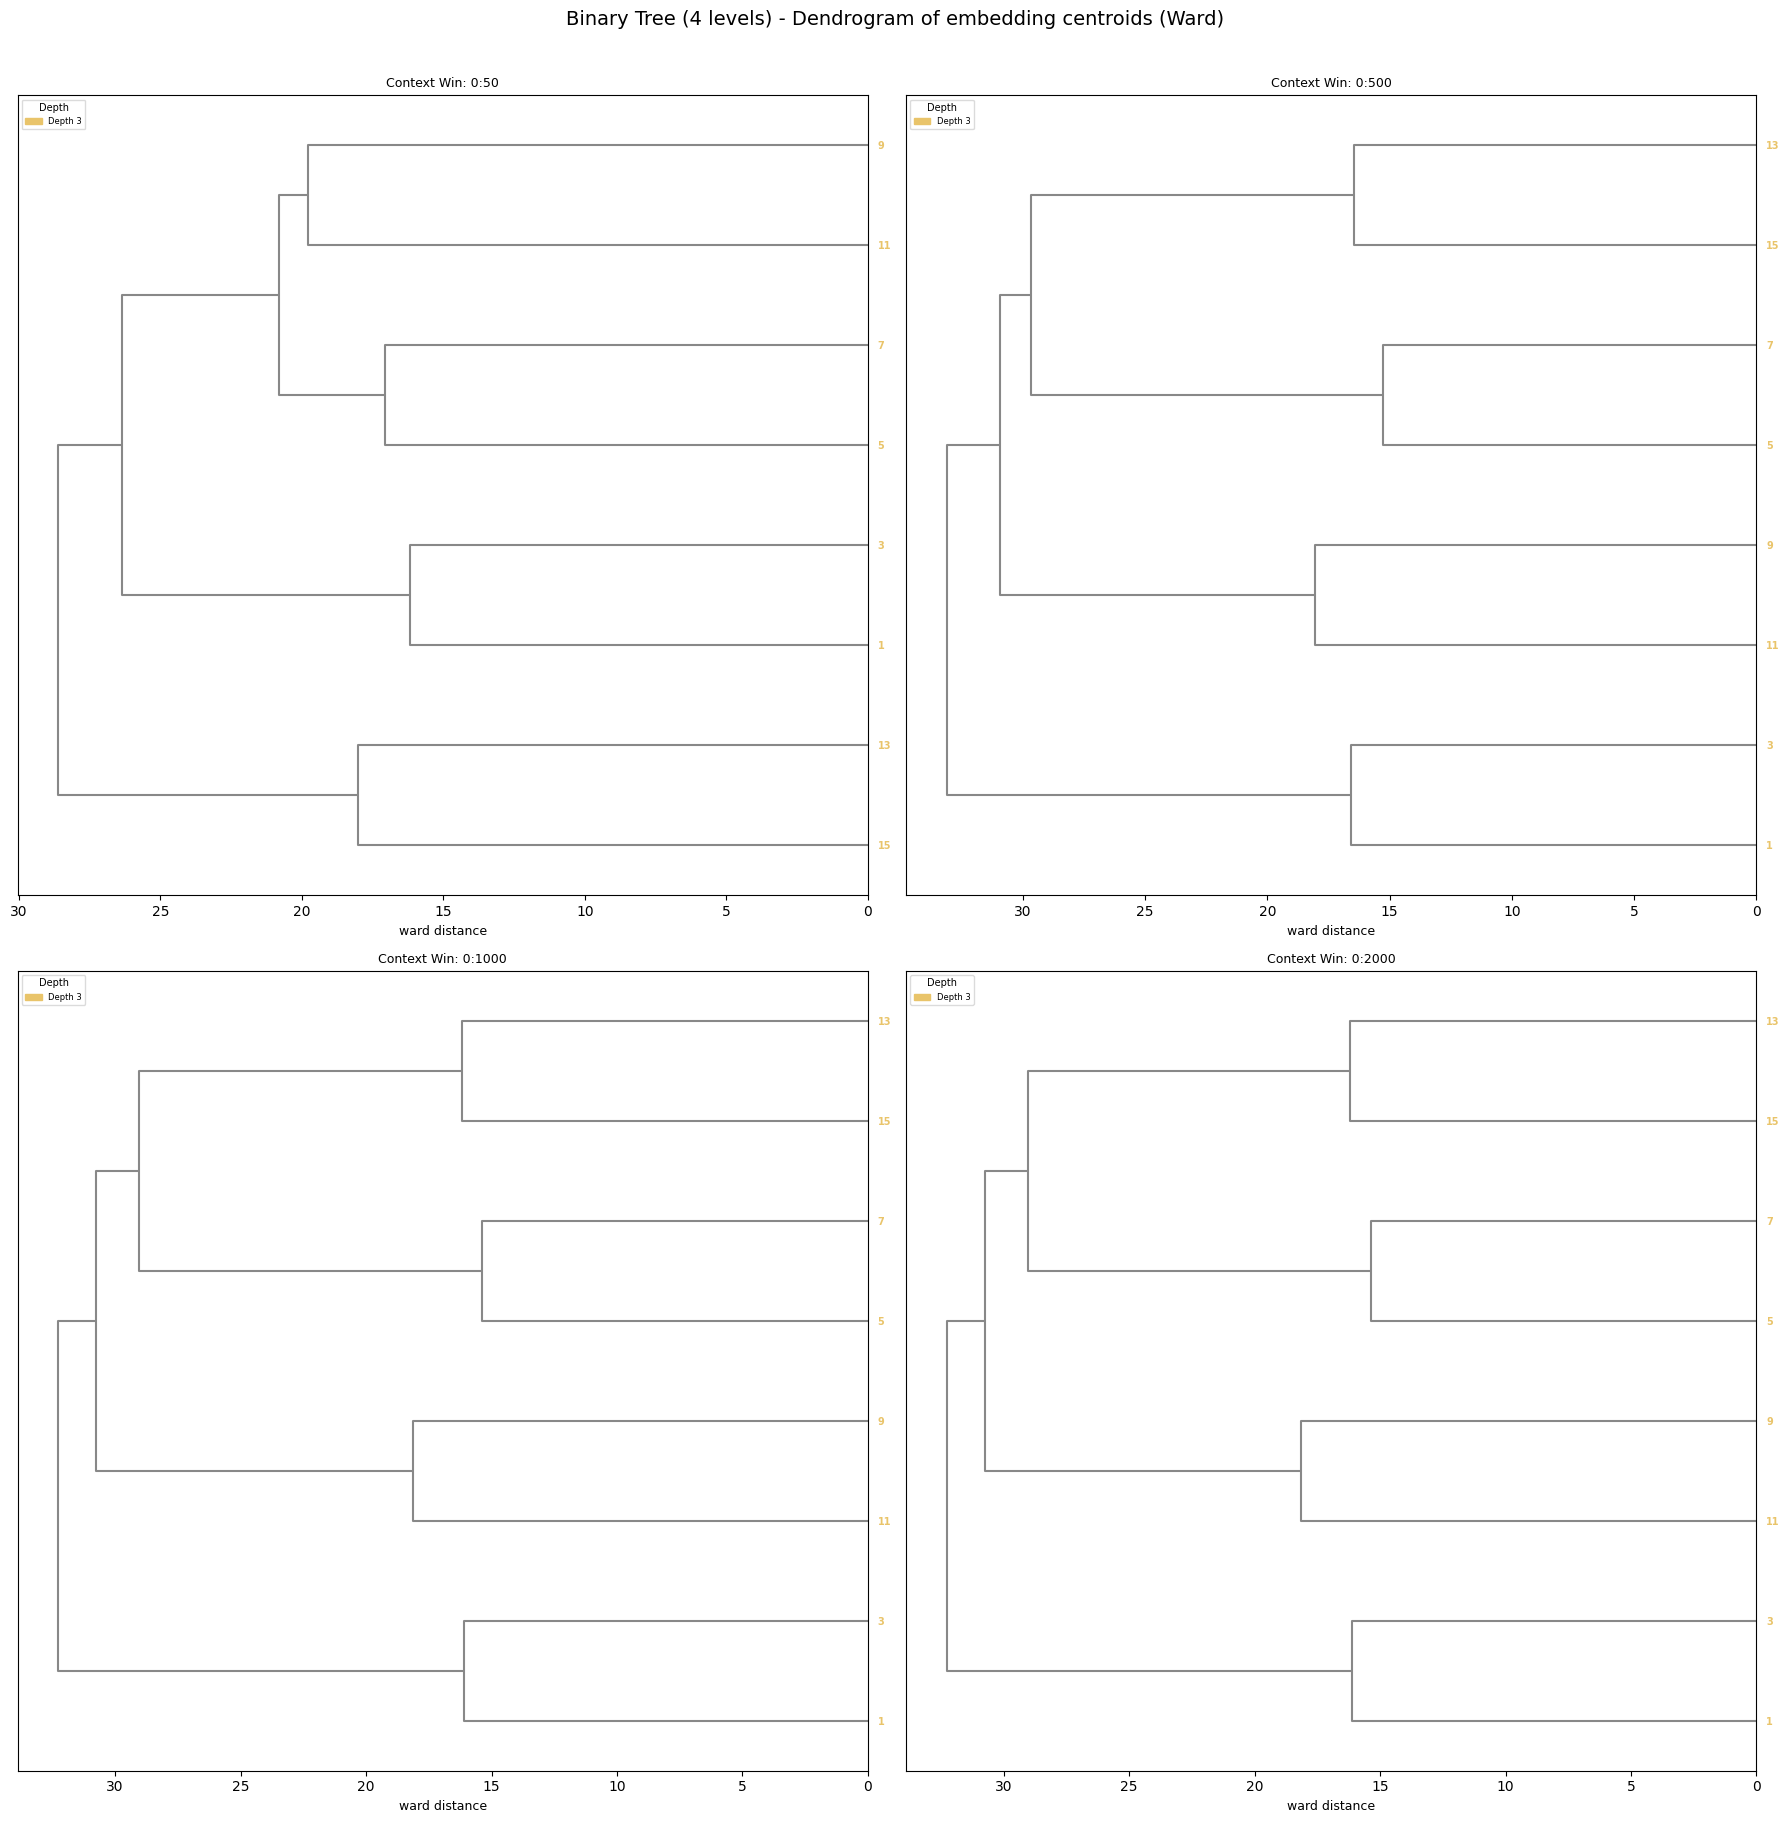

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

layer = 3 # quale livello dell'albero dendrogrammo
layer2 = 3 # quale livello dell'albero dendrogrammo per i centroidi

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer or depth == layer2]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

for ax, win in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {win}")
    pt_path = EMB_DIR / f"reprs_bin_tree_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    mask_layer_l = np.isin(ids_np, ids_layer_l)

    emb_np = emb_np[mask_layer_l]
    ids_np = ids_np[mask_layer_l]

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, k=10, t_end=win)

    centroids_id, centroids_emb = centroids_by_token(filtered_ids, filtered_embs)

    hp_tree.plot_dendrogram_on_points(ax, centroids_id, centroids_emb, title=f"Context Win: 0:{win}", method="ward", max_leaves=50)

fig.suptitle("Binary Tree (4 levels) - Dendrogram of embedding centroids (Ward)",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Exp 2.1: Numbers Tree - leaves only

  [] Warning: token '15' has only 9 occurrences in [0:50] (requested 10)
  [] Warning: token '3' has only 2 occurrences in [0:50] (requested 10)
  [] Warning: token '5' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '1' has only 3 occurrences in [0:150] (requested 10)
  [] Warning: token '3' has only 7 occurrences in [0:150] (requested 10)
  [] Warning: token '5' has only 9 occurrences in [0:150] (requested 10)
  [] Warning: token '7' has only 3 occurrences in [0:150] (requested 10)
  [] Warning: token '9' has only 5 occurrences in [0:150] (requested 10)


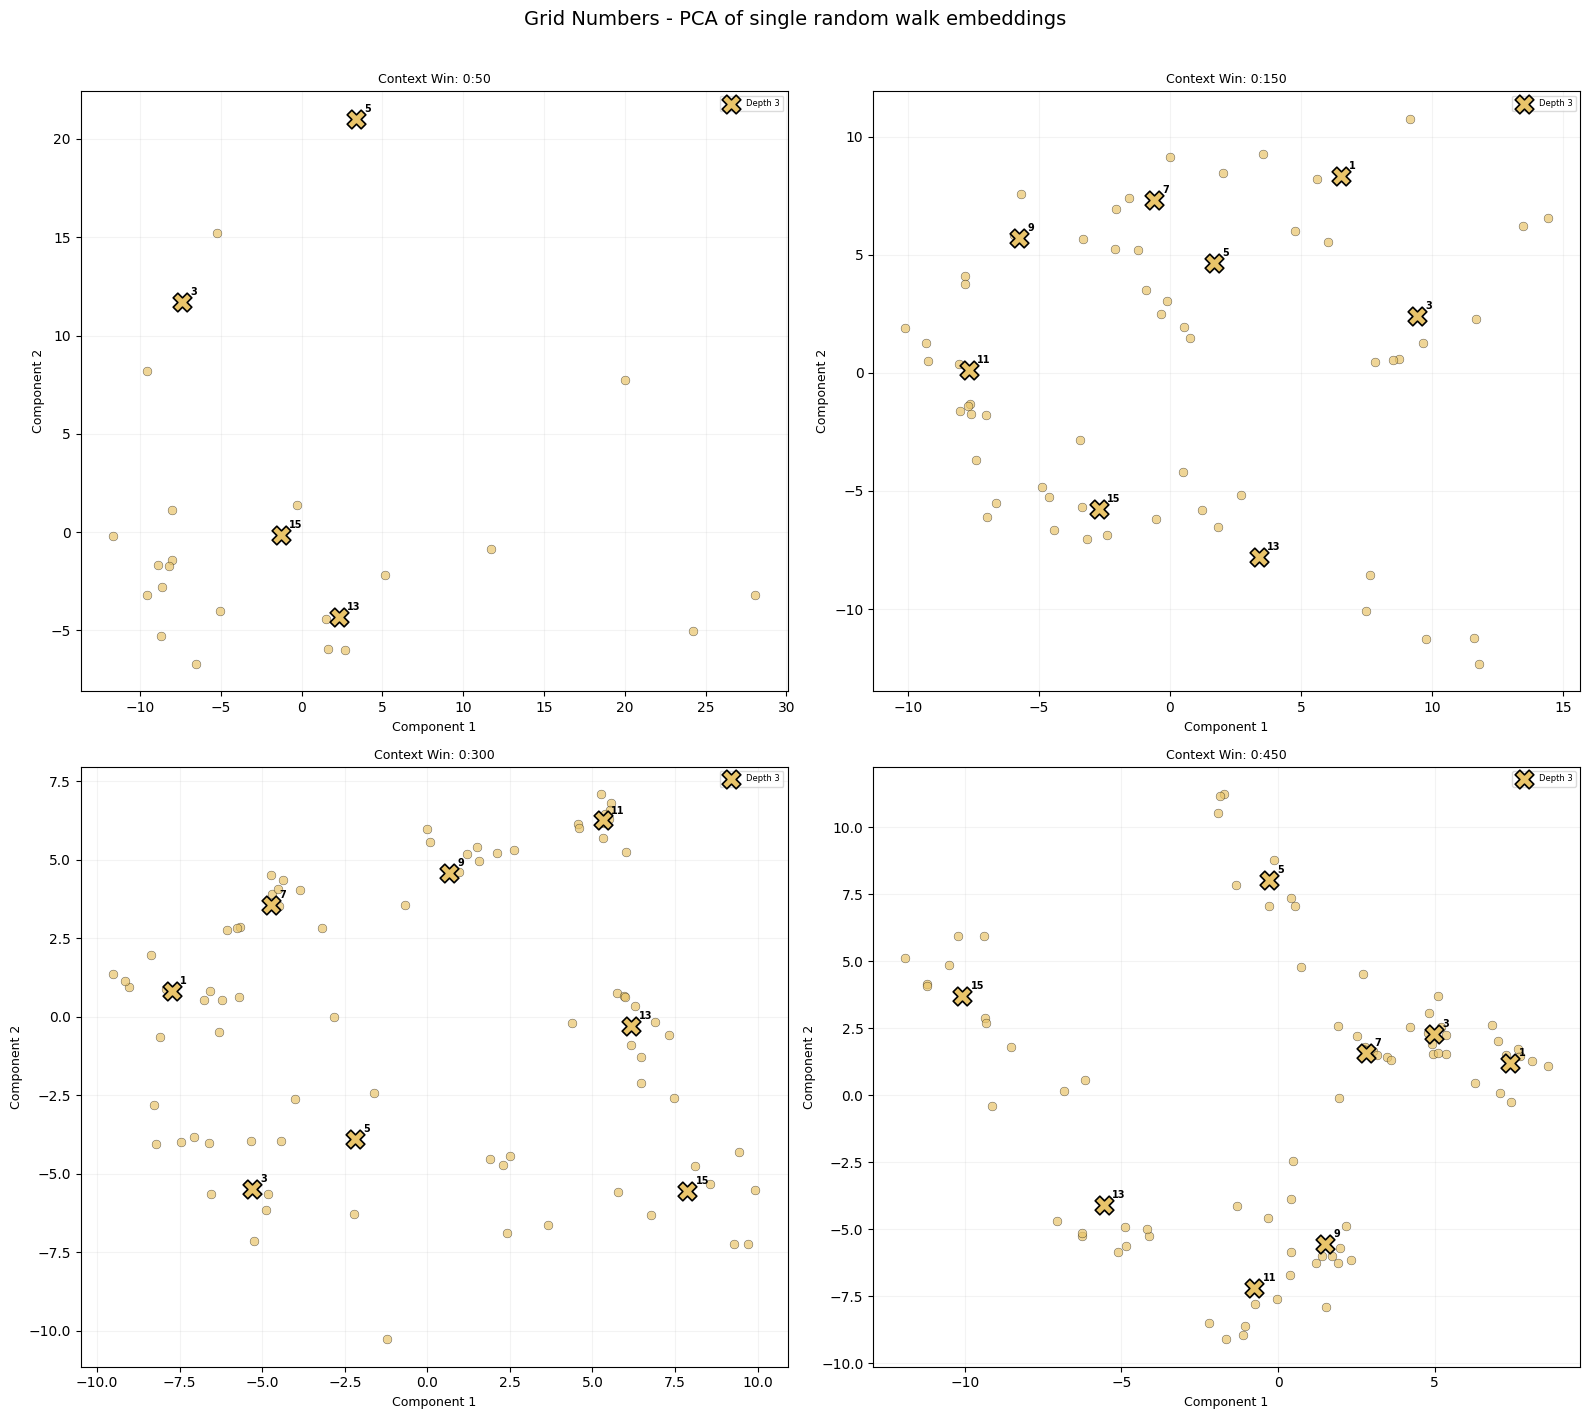

In [ ]:
EMB_DIR     = Path("../embeddings/numbers/only_leaves_tree")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/only_leaves_tree/tree_structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [50,150, 300, 450]


for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_tree_only_leaves_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(filtered_embs)

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle("Grid Numbers - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

Processing context length: 50
  [] Warning: token '11' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '1' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token '3' has only 7 occurrences in [0:50] (requested 10)
  [] Warning: token '5' has only 7 occurrences in [0:50] (requested 10)
  [] Warning: token '7' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token '9' has only 1 occurrences in [0:50] (requested 10)
Processing context length: 150
Processing context length: 300
Processing context length: 450


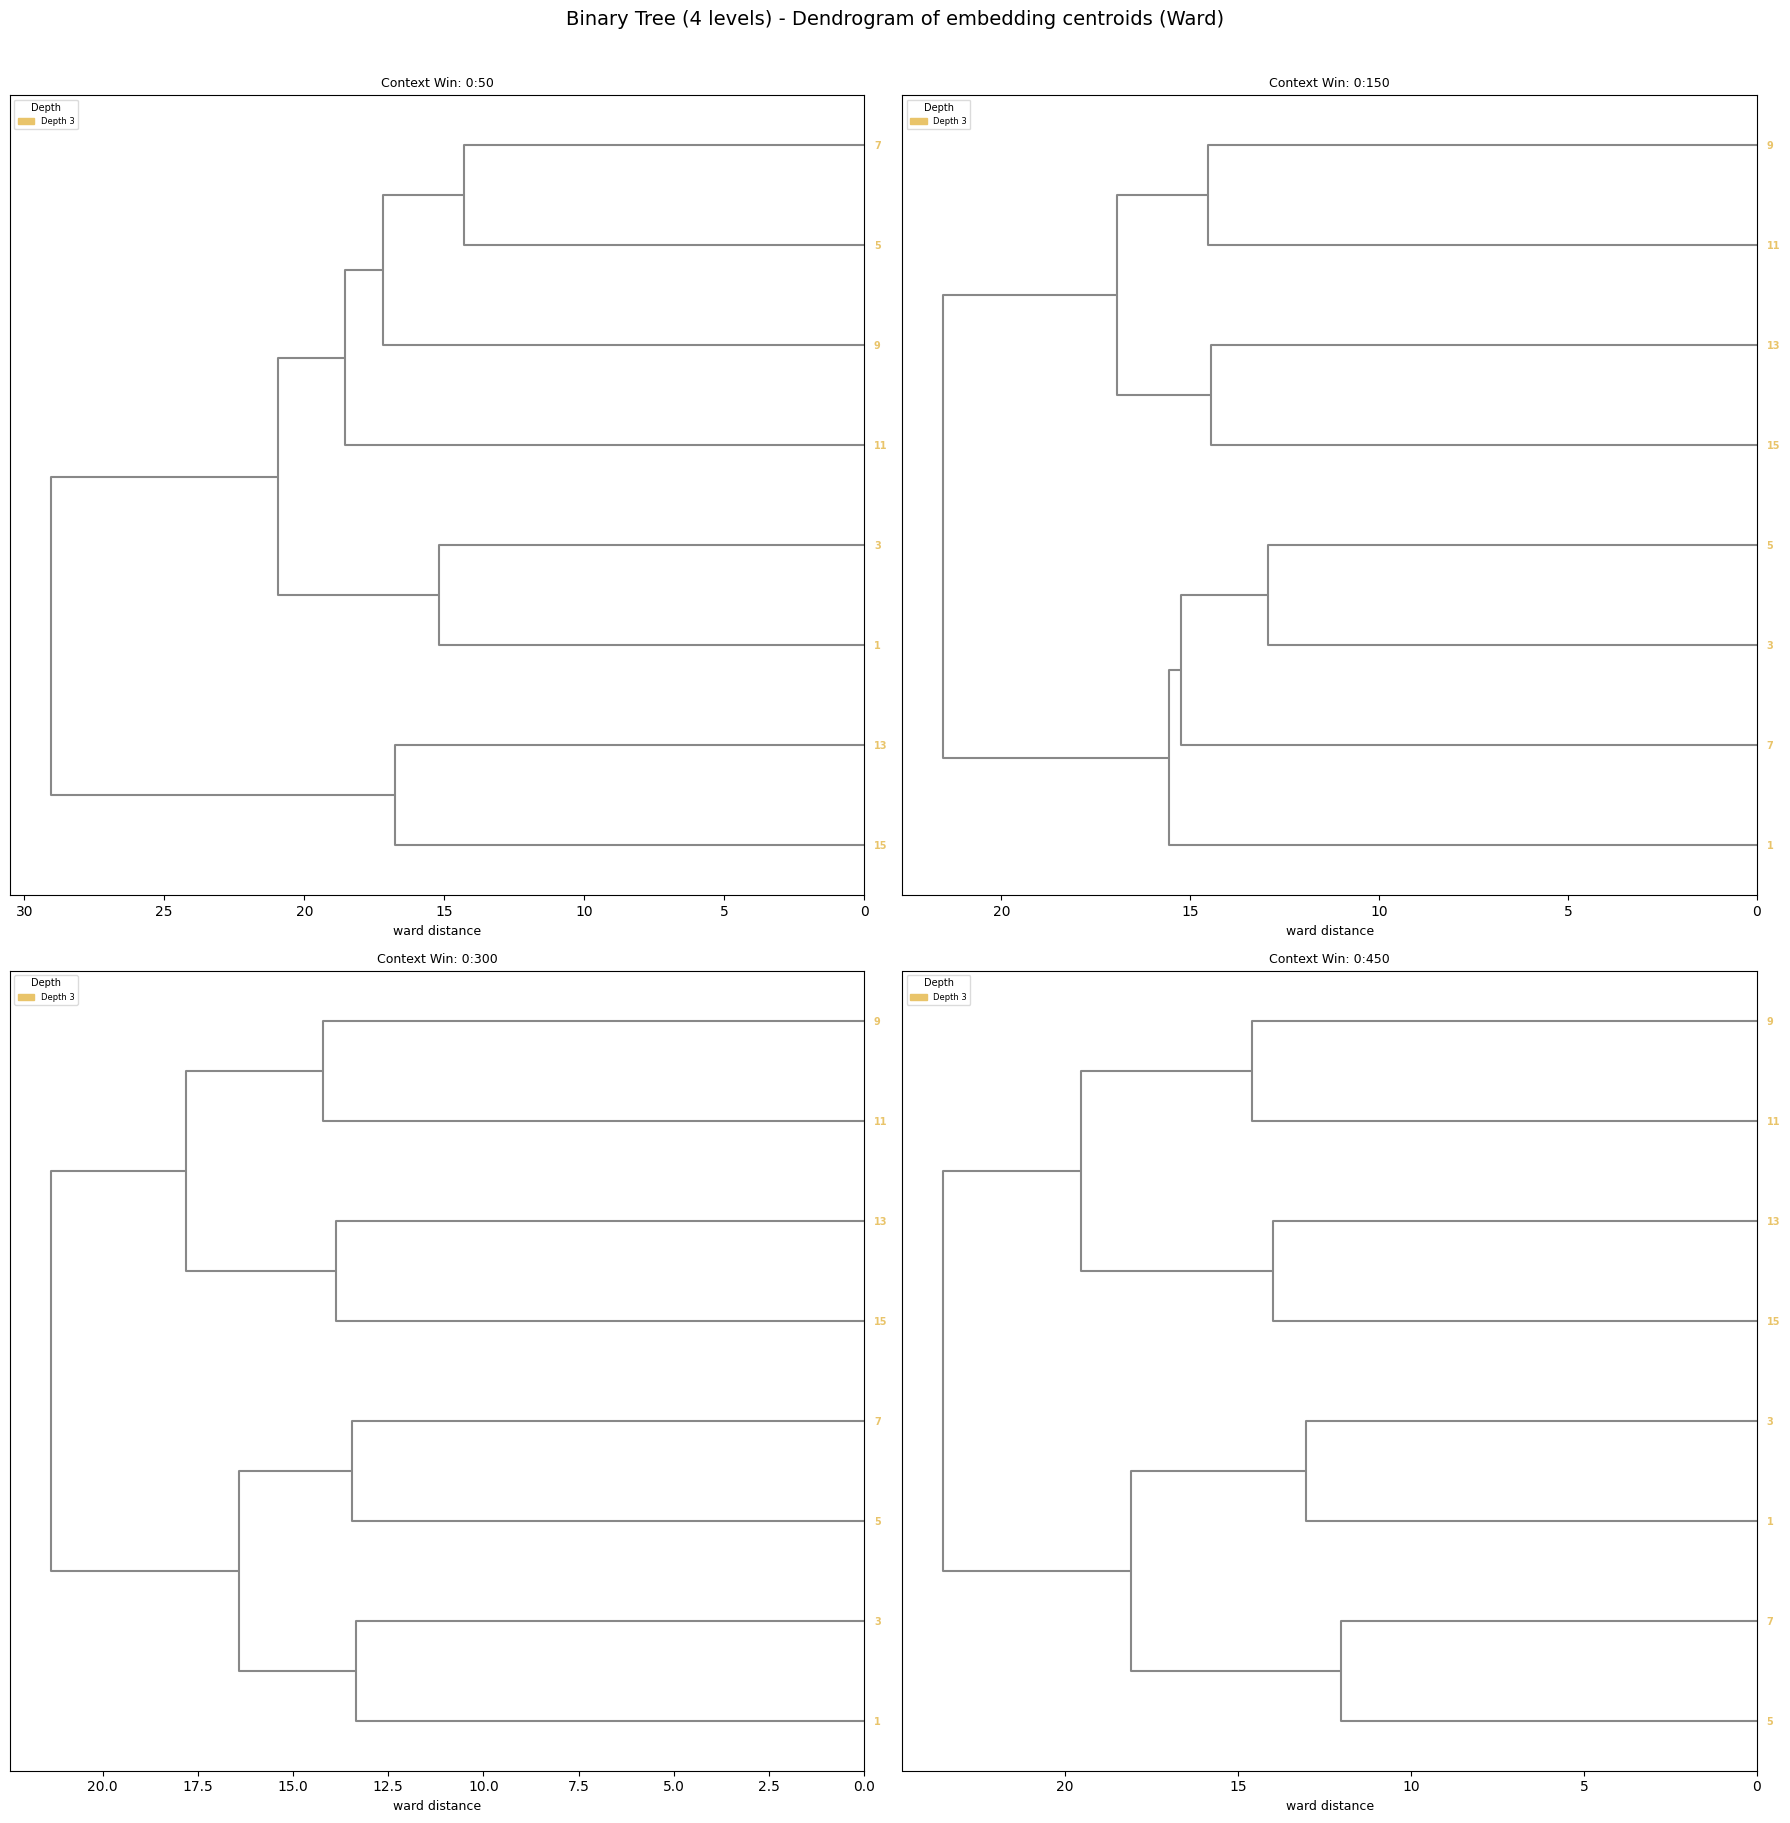

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

layer = 3 # quale livello dell'albero dendrogrammo

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

for ax, win in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {win}")
    pt_path = EMB_DIR / f"reprs_tree_only_leaves_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    mask_layer_l = np.isin(ids_np, ids_layer_l)

    emb_np = emb_np[mask_layer_l]
    ids_np = ids_np[mask_layer_l]

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, k=10, t_end=win)

    centroids_id, centroids_emb = centroids_by_token(filtered_ids, filtered_embs)

    hp_tree.plot_dendrogram_on_points(ax, centroids_id, centroids_emb, title=f"Context Win: 0:{win}", method="ward", max_leaves=50)

fig.suptitle("Binary Tree (4 levels) - Dendrogram of embedding centroids (Ward)",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Exp 2.2: Numbers Tree - leaves only (shuffled)

  [] Warning: token '2' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '5' has only 2 occurrences in [0:50] (requested 10)
  [] Warning: token '7' has only 9 occurrences in [0:50] (requested 10)
  [] Warning: token '12' has only 3 occurrences in [0:150] (requested 10)
  [] Warning: token '2' has only 9 occurrences in [0:150] (requested 10)
  [] Warning: token '5' has only 7 occurrences in [0:150] (requested 10)
  [] Warning: token '6' has only 3 occurrences in [0:150] (requested 10)
  [] Warning: token '9' has only 5 occurrences in [0:150] (requested 10)


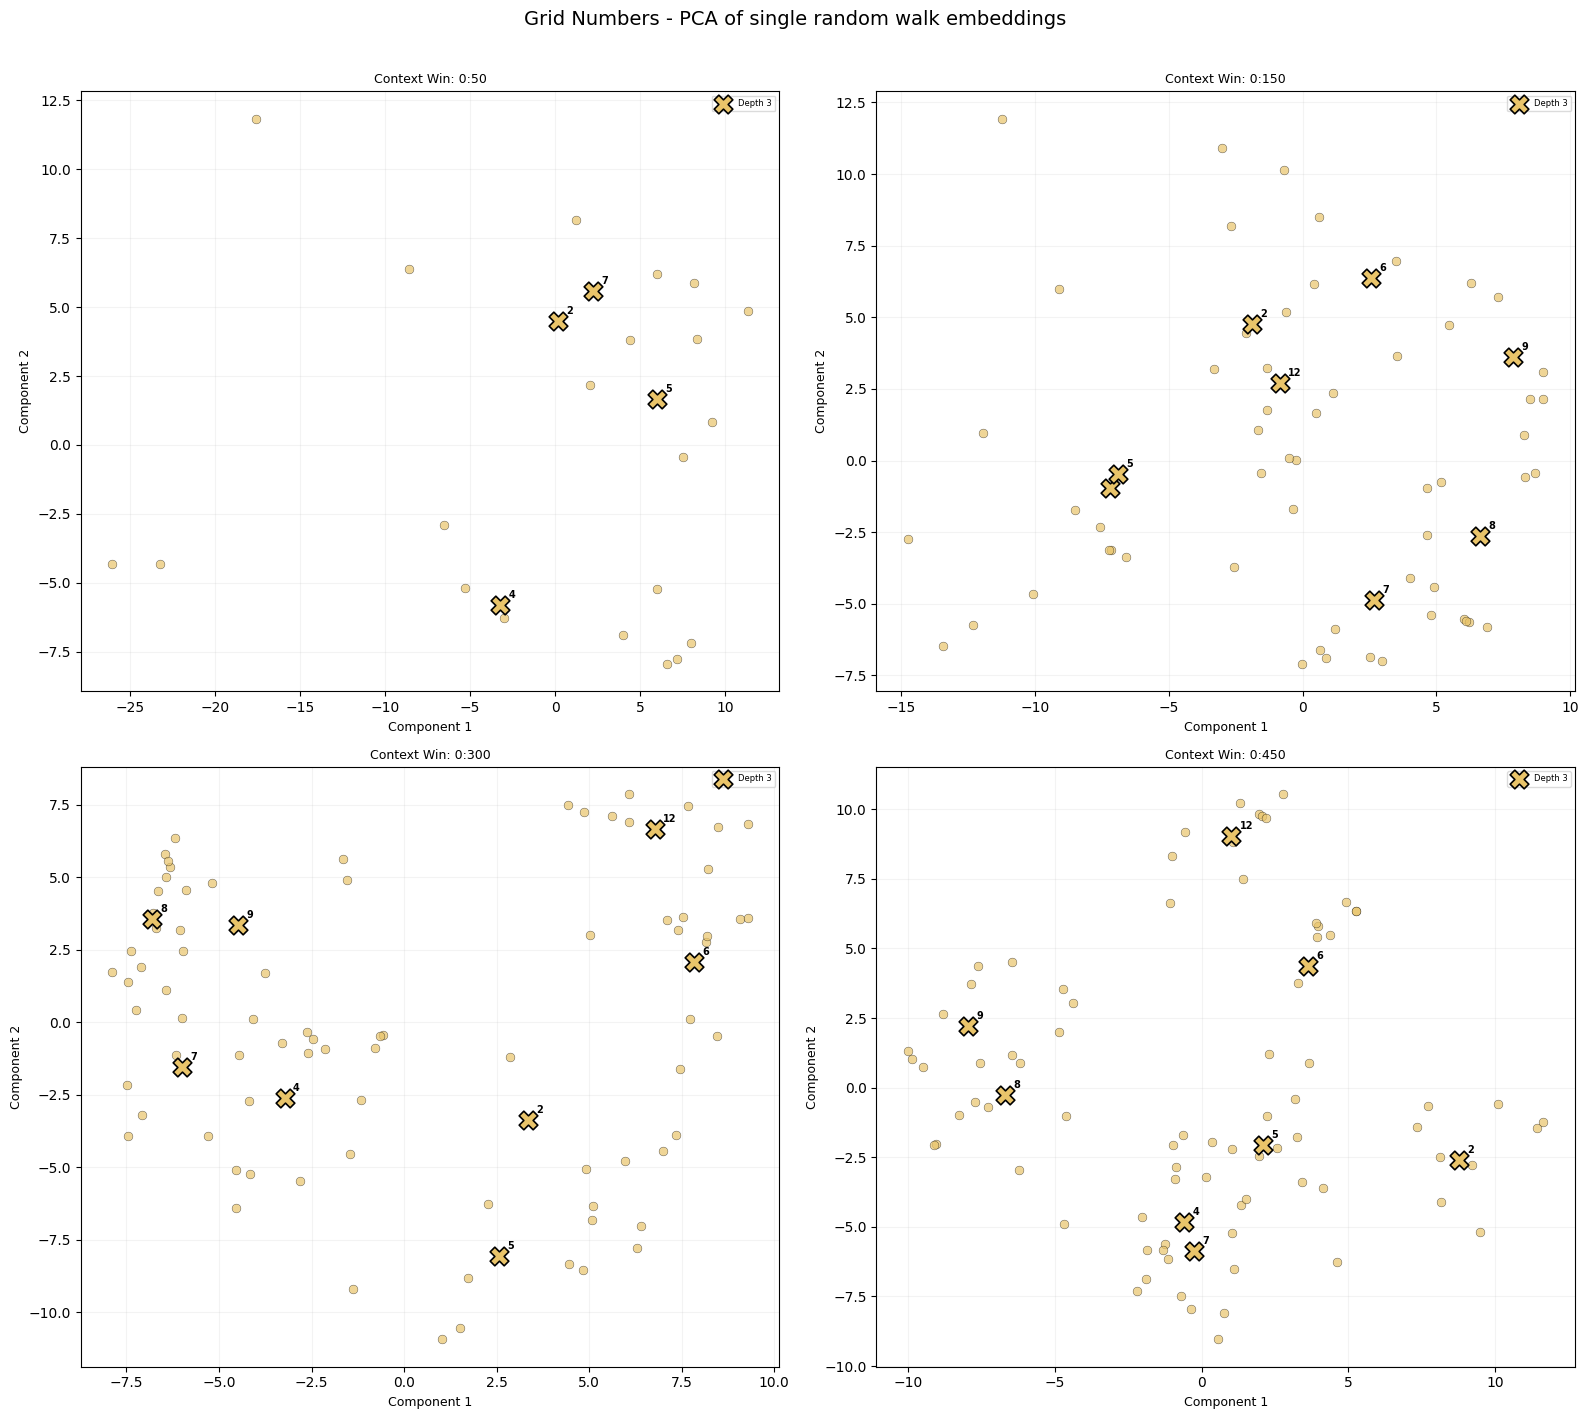

In [24]:
EMB_DIR     = Path("../embeddings/numbers/only_leaves_shuffled_tree")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/only_leaves_shuffled_tree/tree_structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [50,150, 300, 450]


for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_tree_only_leaves_shuffled_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(filtered_embs)

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle("Grid Numbers - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

Processing context length: 50
  [] Warning: token '12' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token '2' has only 7 occurrences in [0:50] (requested 10)
  [] Warning: token '5' has only 7 occurrences in [0:50] (requested 10)
  [] Warning: token '6' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token '8' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '9' has only 1 occurrences in [0:50] (requested 10)
Processing context length: 150
Processing context length: 300
Processing context length: 450


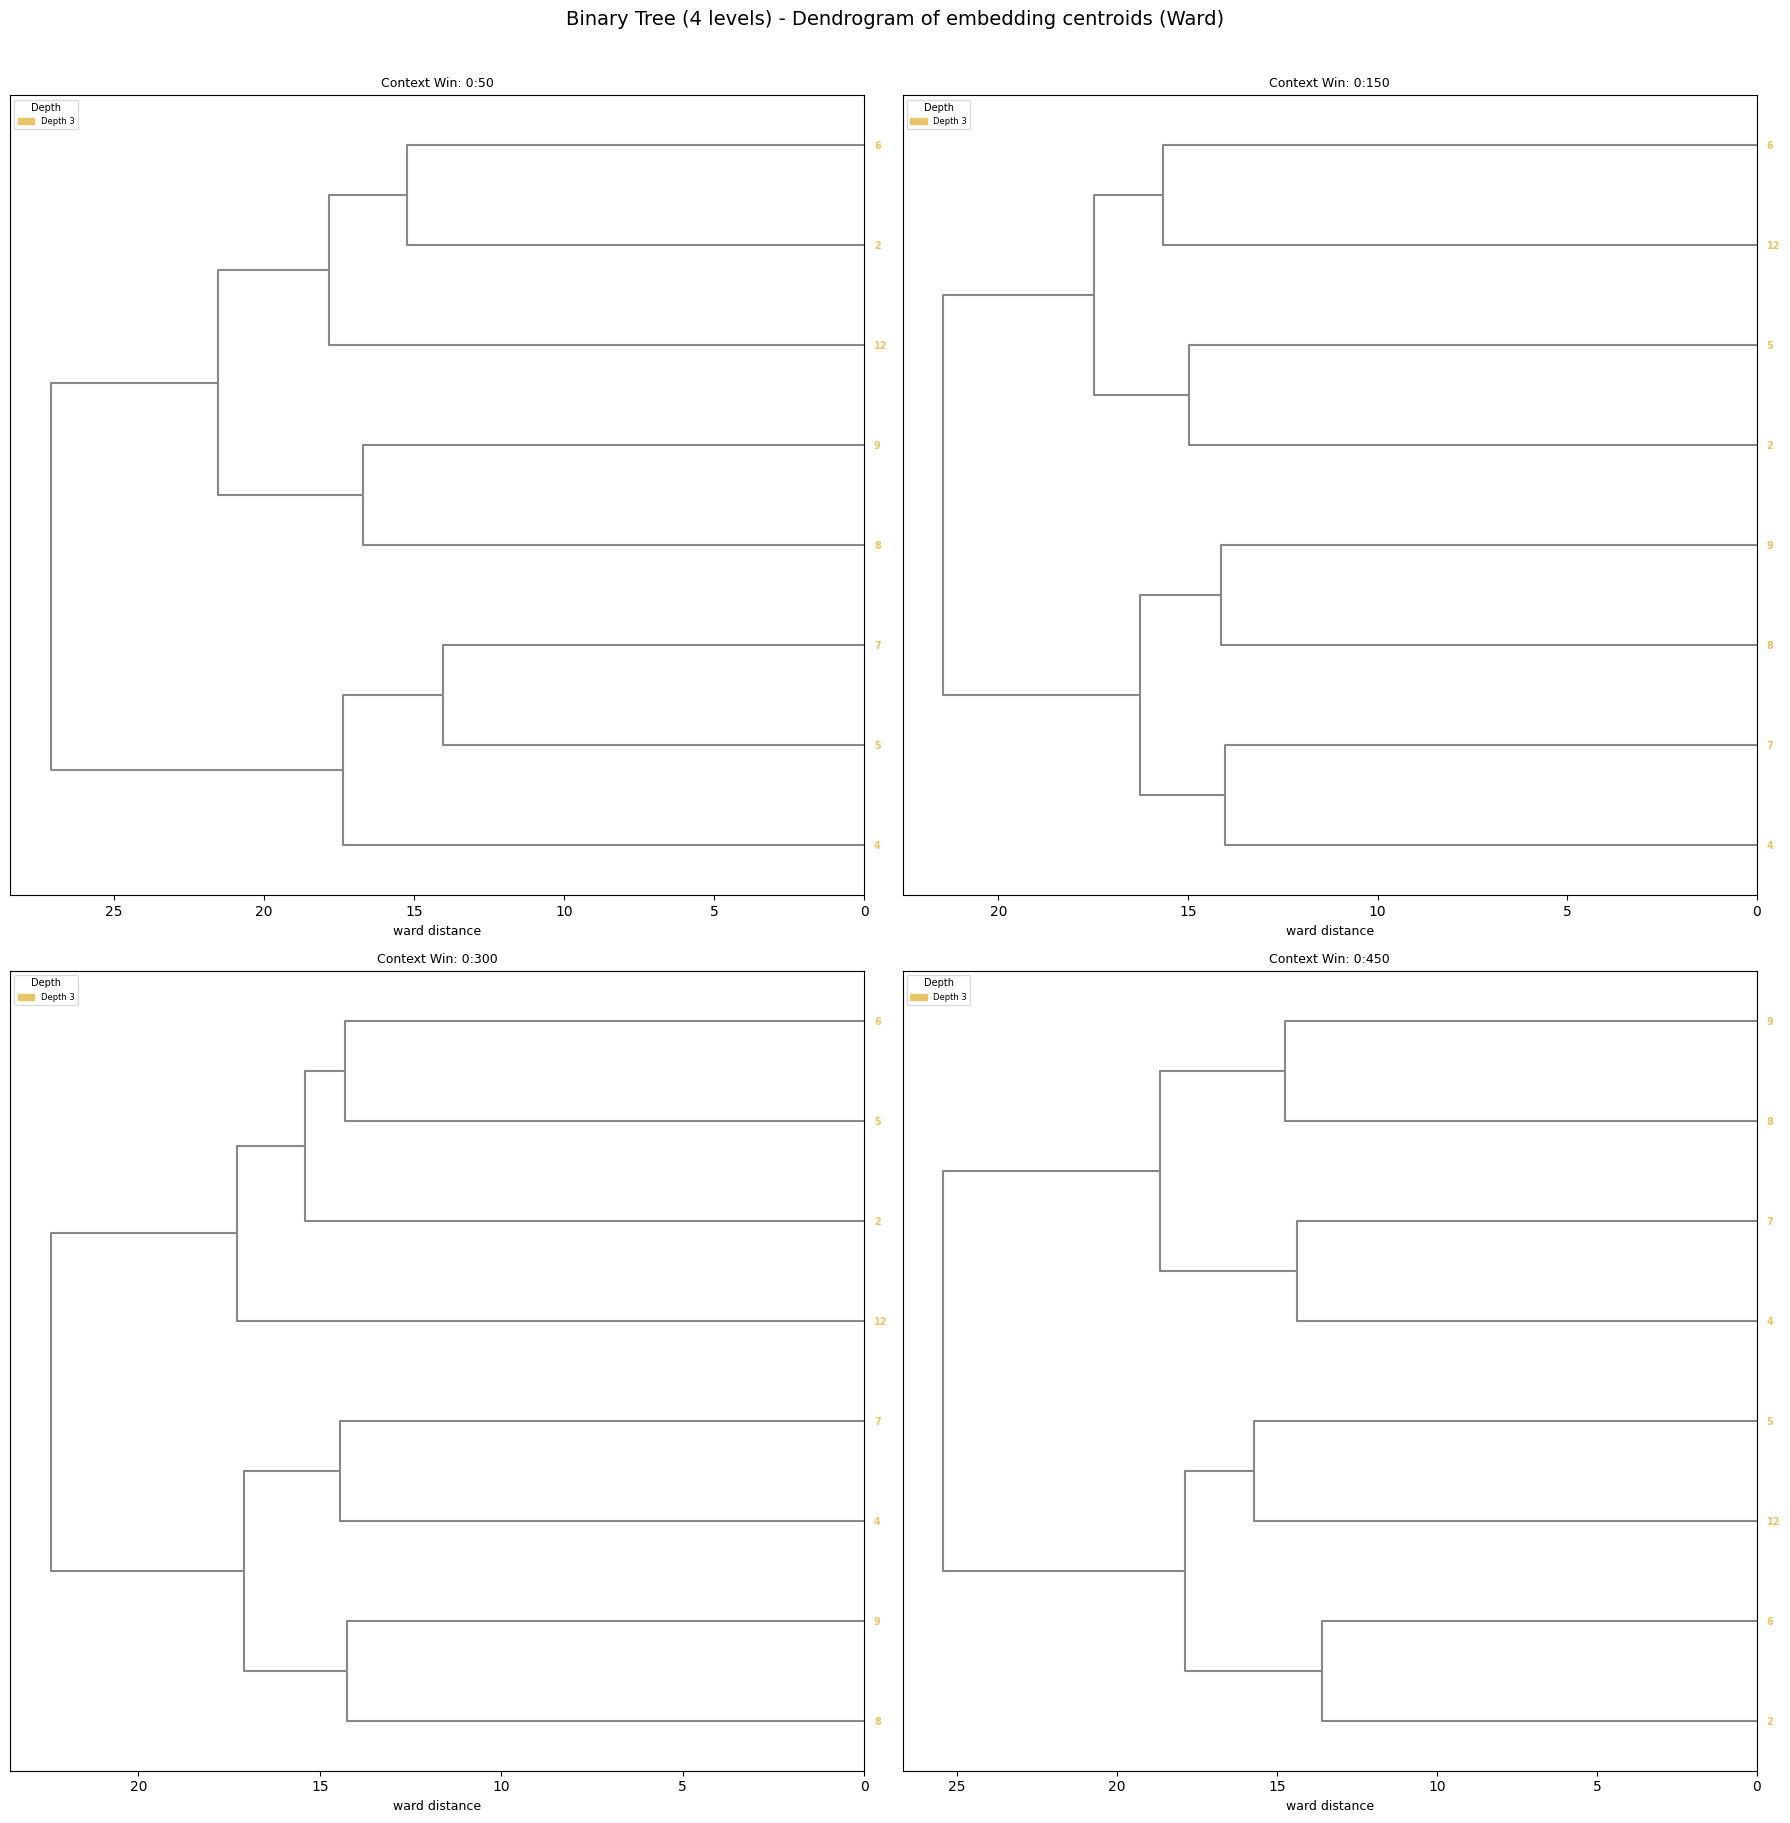

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

layer = 3 # quale livello dell'albero dendrogrammo

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

for ax, win in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {win}")
    pt_path = EMB_DIR / f"reprs_tree_only_leaves_shuffled_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    mask_layer_l = np.isin(ids_np, ids_layer_l)

    emb_np = emb_np[mask_layer_l]
    ids_np = ids_np[mask_layer_l]

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, k=10, t_end=win)

    centroids_id, centroids_emb = centroids_by_token(filtered_ids, filtered_embs)

    hp_tree.plot_dendrogram_on_points(ax, centroids_id, centroids_emb, title=f"Context Win: 0:{win}", method="ward", max_leaves=50)

fig.suptitle("Binary Tree (4 levels) - Dendrogram of embedding centroids (Ward)",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

# QUADRATI E CERCHI

## Exp 4: Numbers Circle (ordered) - IN ORDER TRAVERSAL

In [ ]:
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/circle_numbers/circle_structure.txt")
EMB_DIR     = Path("../embeddings/numbers/circle_numbers")

hp_circle_num = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

ctx = 2000
CTX_LENS = [50,500, 1000, 2000]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_circle_numbers_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_circle_num.id_to_word, 
                                                     k=5, t_start=0, t_end=win_len)
    reducer = PCA(n_components=2, random_state=0)
    pca_result = reducer.fit_transform(filtered_embs)
    hp_circle_num.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

  [] Warning: token '15' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token '13' has only 2 occurrences in [0:50] (requested 5)
  [] Warning: token '12' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token '14' has only 2 occurrences in [0:50] (requested 5)
  [] Warning: token '1' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token '2' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token '4' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token '5' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token '7' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token '8' has only 3 occurrences in [0:50] (requested 5)
  [] Warning: token '9' has only 4 occurrences in [0:50] (requested 5)
  [] Warning: token '10' has only 2 occurrences in [0:50] (requested 5)


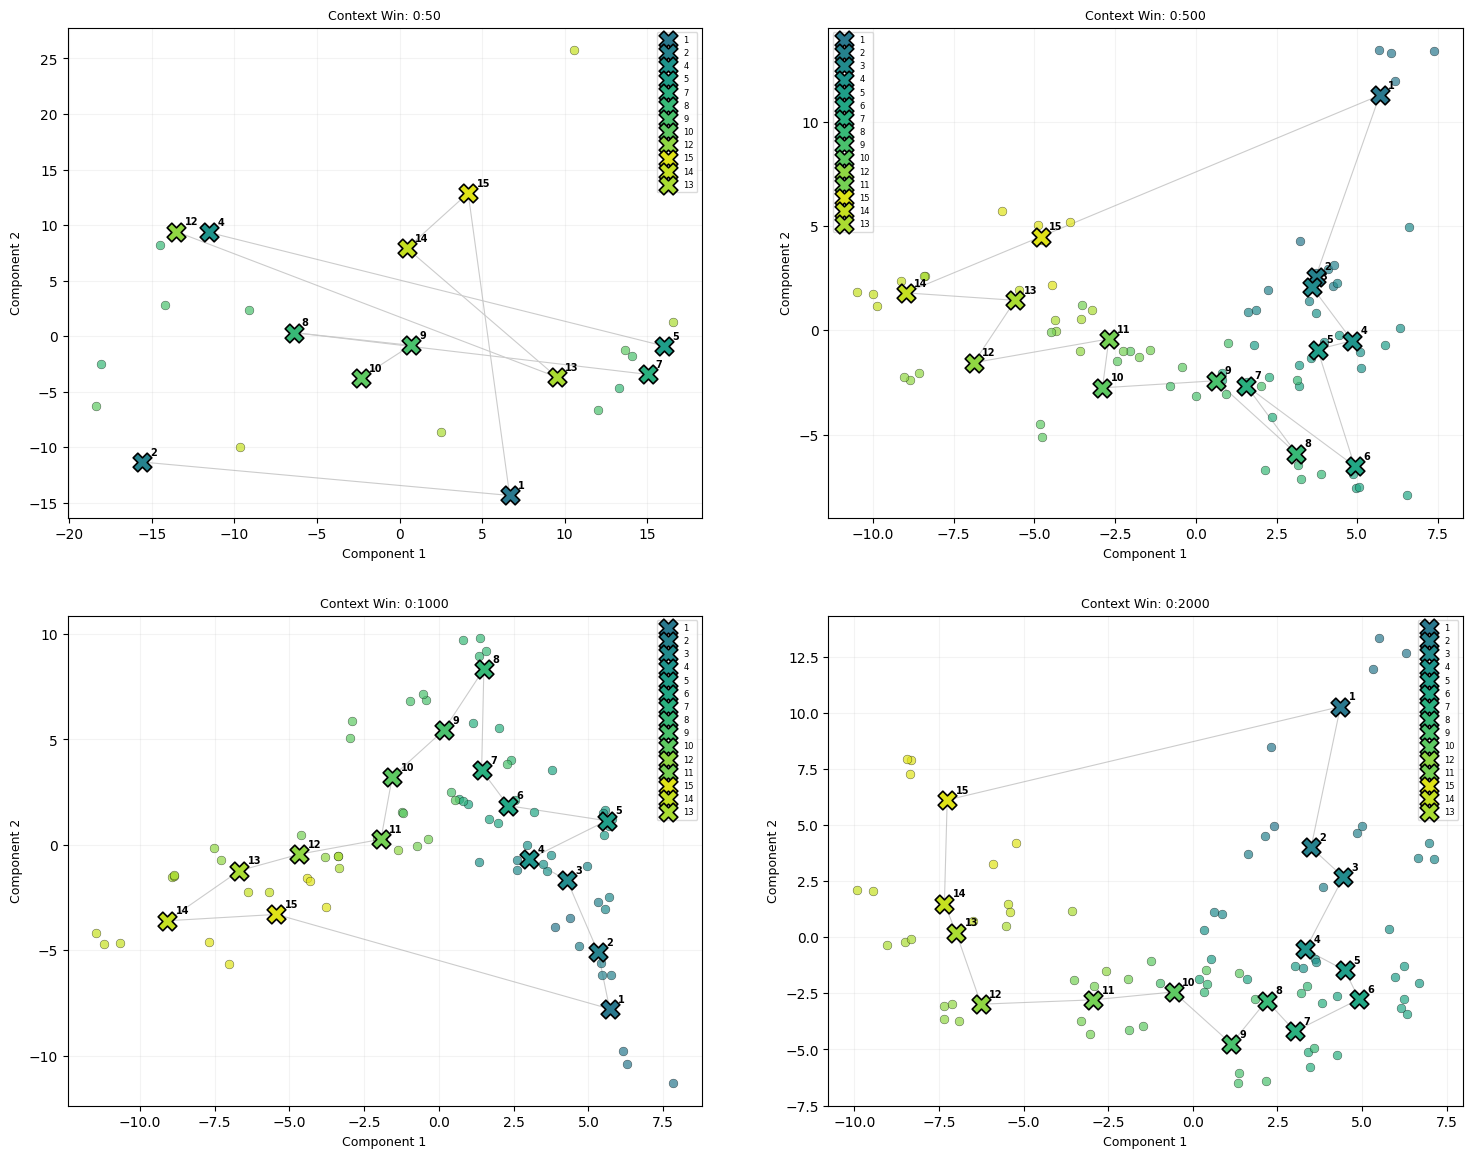

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

ctx = 2000
CTX_LENS = [50,500, 1000, 2000]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_circle_numbers_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_circle_num.id_to_word, 
                                                     k=5, t_start=0, t_end=win_len)
    reducer = PCA(n_components=3, random_state=0)
    pca_result = reducer.fit_transform(filtered_embs)[:,1:3]
    hp_circle_num.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

## Exp 5: Numbers Grid (ordered) - IN ORDER TRAVERSAL

  [] Warning: token '15' has only 1 occurrences in [0:100] (requested 10)
  [] Warning: token '11' has only 1 occurrences in [0:100] (requested 10)
  [] Warning: token '13' has only 3 occurrences in [0:100] (requested 10)
  [] Warning: token '12' has only 3 occurrences in [0:100] (requested 10)
  [] Warning: token '14' has only 1 occurrences in [0:100] (requested 10)
  [] Warning: token '1' has only 3 occurrences in [0:100] (requested 10)
  [] Warning: token '2' has only 6 occurrences in [0:100] (requested 10)
  [] Warning: token '3' has only 6 occurrences in [0:100] (requested 10)
  [] Warning: token '4' has only 7 occurrences in [0:100] (requested 10)
  [] Warning: token '5' has only 2 occurrences in [0:100] (requested 10)
  [] Warning: token '6' has only 3 occurrences in [0:100] (requested 10)
  [] Warning: token '7' has only 5 occurrences in [0:100] (requested 10)
  [] Warning: token '8' has only 3 occurrences in [0:100] (requested 10)
  [] Warning: token '9' has only 4 occurrences

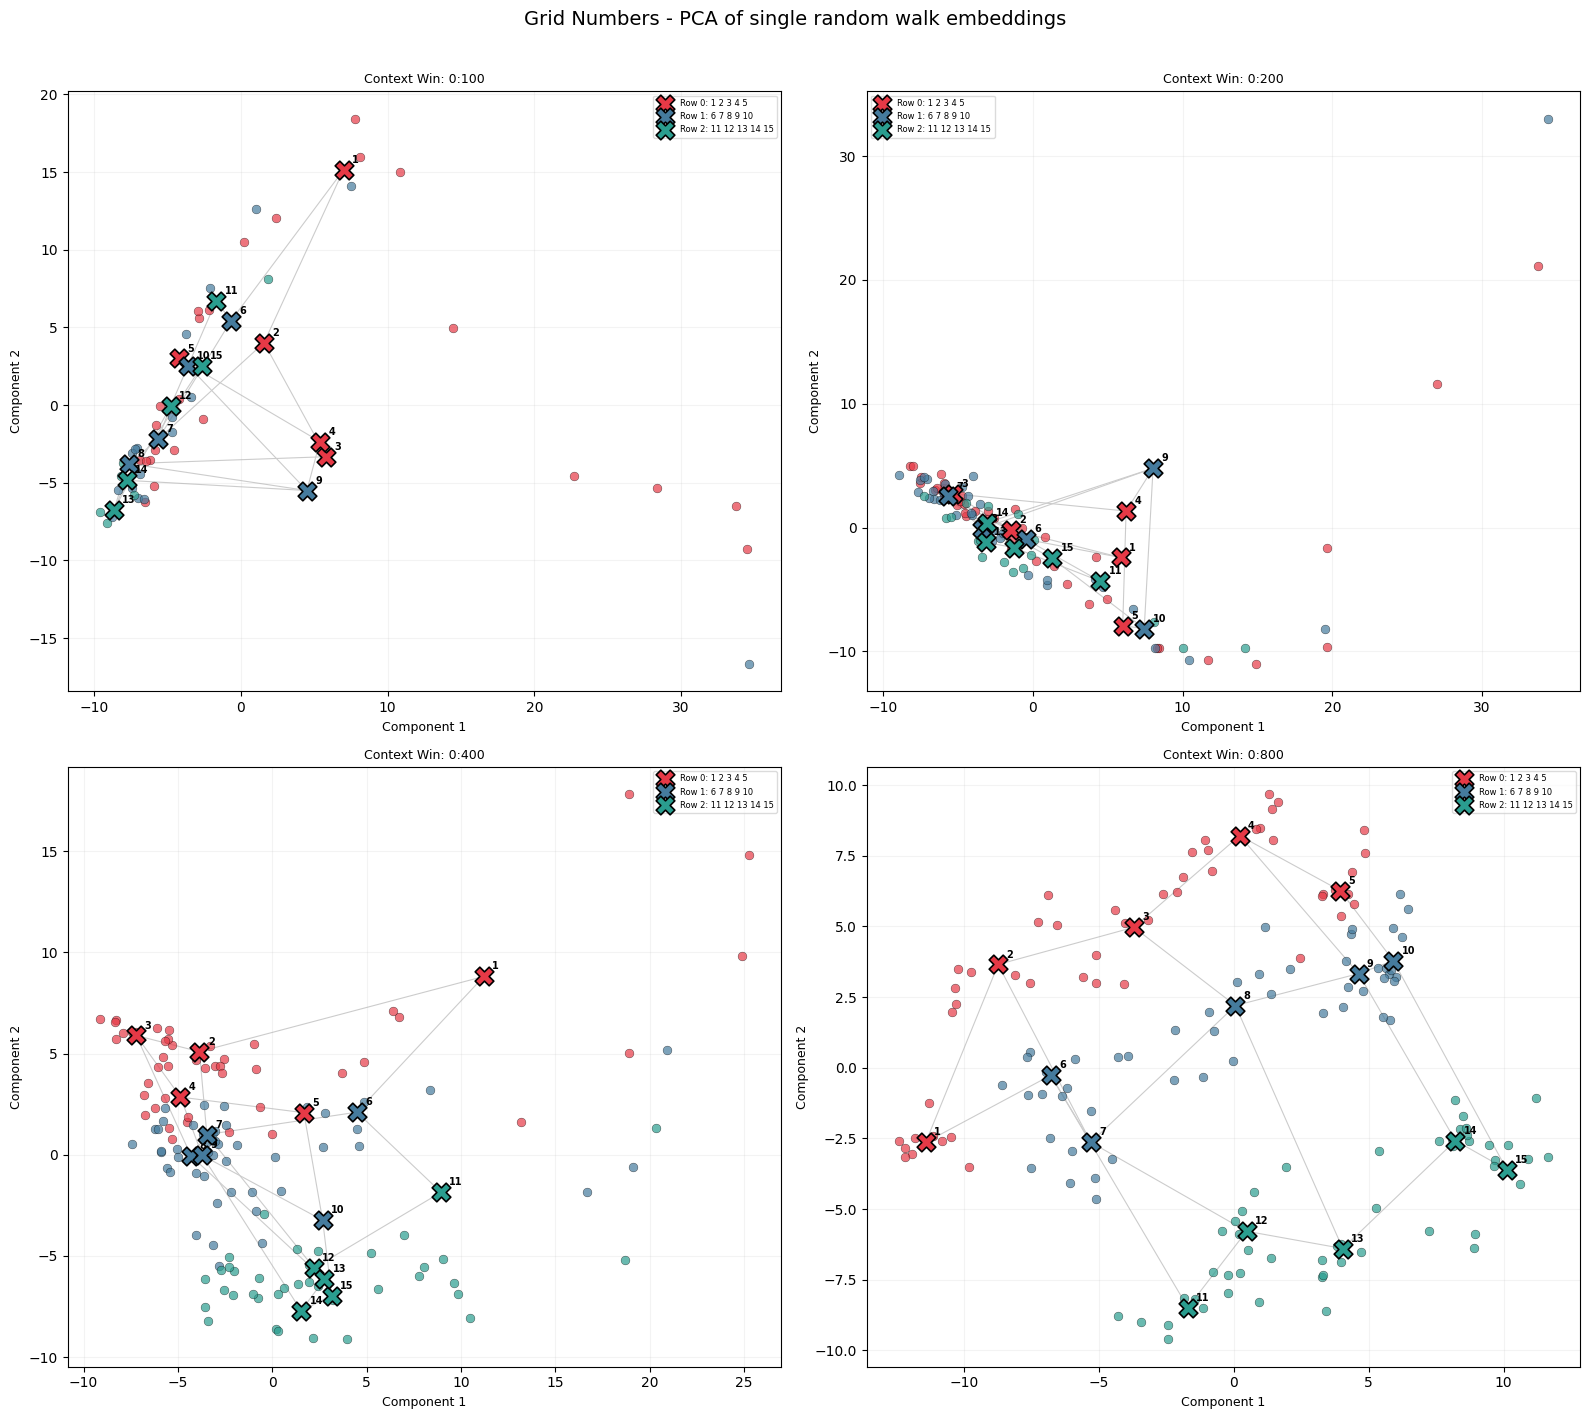

In [3]:
EMB_DIR     = Path("../embeddings/numbers/grid_numbers")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/grid_numbers/grid_structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [100,200,400,800]


for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_grid_numbers_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(filtered_embs)

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle("Grid Numbers - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

# GIORNI

## Days Tree (3 levels)

  [] Warning: token 'Wednesday' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token 'Sunday' has only 1 occurrences in [0:50] (requested 10)


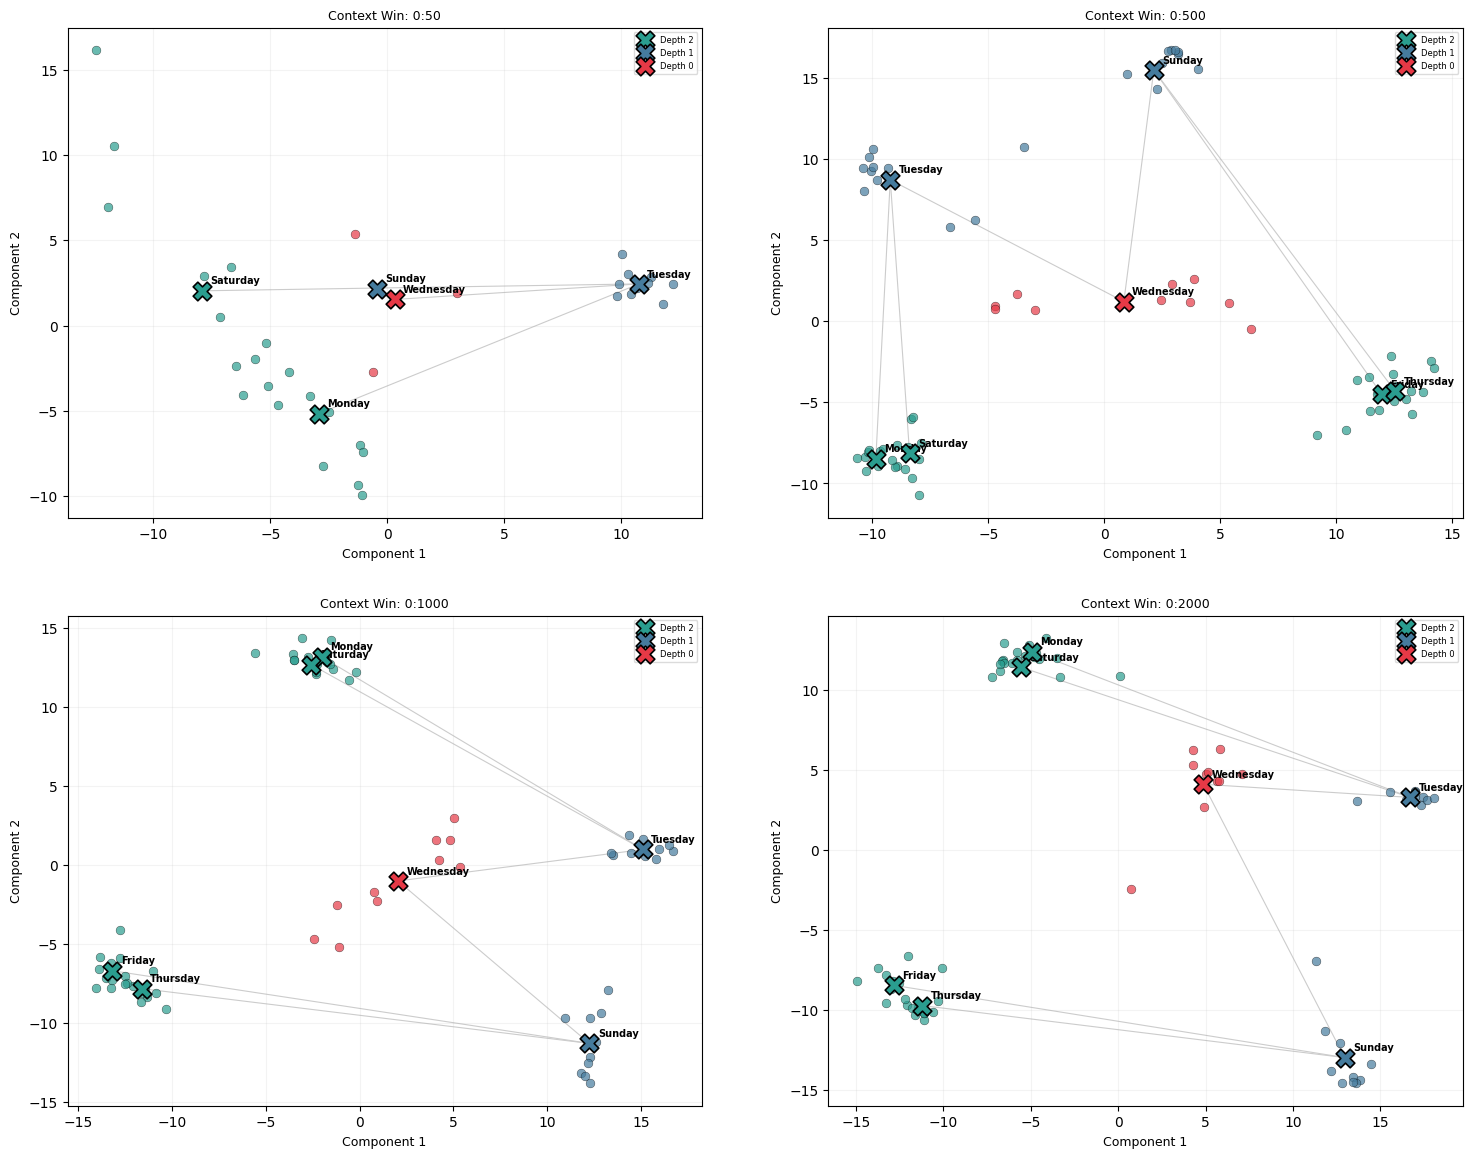

In [ ]:
VOCAB_PATH  = Path("../data/days_tkid_map.txt")
STRUCT_PATH = Path("../data/one_random_walk/tree_days/bin_tree_structure.txt")
EMB_DIR     = Path("../embeddings/numbers/tree_days")

hp_tree_das = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)


fig, axes = plt.subplots(2, 2, figsize=(18, 14))

ctx = 2000
CTX_LENS = [50,500, 1000, 2000]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_bin_tree_days_dataset_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree_das.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    reducer = PCA(n_components=2, random_state=0)
    pca_result = reducer.fit_transform(filtered_embs)
    hp_tree_das.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

Processing context length: 2000, window=50
  after layer filter: n=673
  [] Warning: token 'Thursday' has only 6 occurrences in [0:50] (requested 10)
  [] Warning: token 'Friday' has only 6 occurrences in [0:50] (requested 10)
Processing context length: 2000, window=500
  after layer filter: n=673
Processing context length: 2000, window=1000
  after layer filter: n=673
Processing context length: 2000, window=2000
  after layer filter: n=673


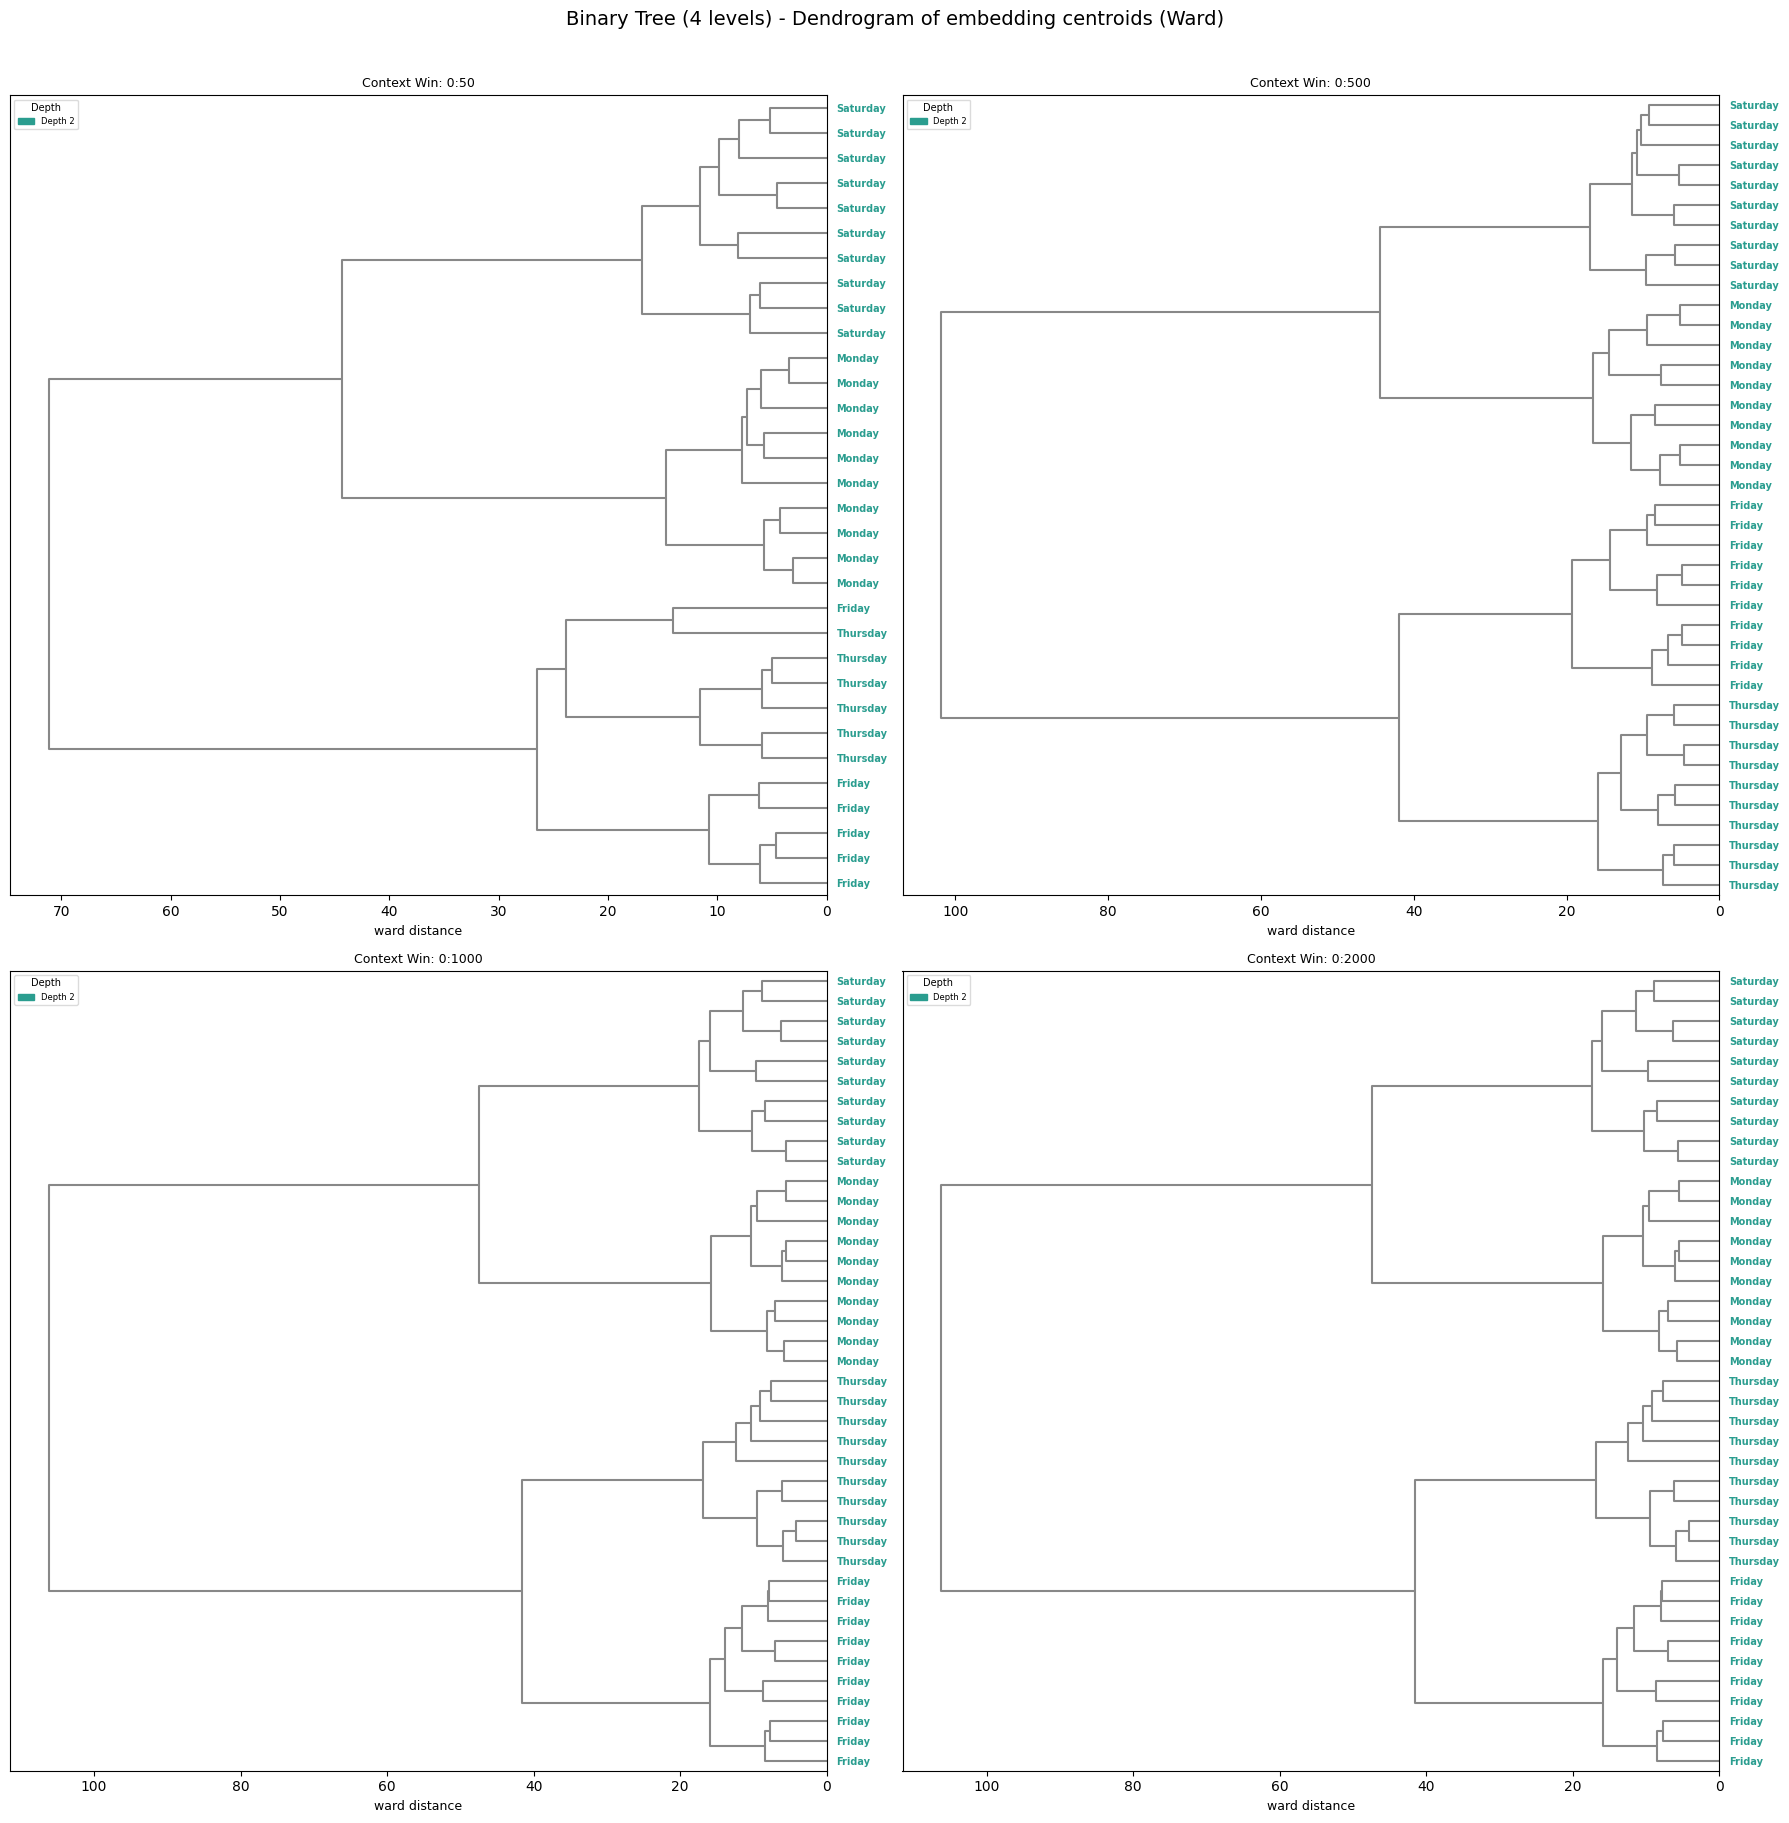

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

layer = 2

toks_layer_l = [toks for toks, depth in hp_tree_das.token_to_group.items() if depth == layer]
ids_layer_l = [hp_tree_das.word_to_tid[tok] for tok in toks_layer_l]

for ax, win_len in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {ctx}, window={win_len}")
    pt_path = EMB_DIR / f"reprs_bin_tree_days_dataset_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    # Keep only tokens from the selected layer
    mask_layer_l = np.isin(ids_np, ids_layer_l)
    ids_np_l = ids_np[mask_layer_l]
    emb_np_l = emb_np[mask_layer_l]

    print(f"  after layer filter: n={len(ids_np_l)}")

    filtered_ids, filtered_embs = _window_and_filter(
        ids_np_l,
        emb_np_l,
        hp_tree_das.id_to_word,
        k=10,
        t_end=win_len
    )

    hp_tree_das.plot_dendrogram_on_points(
        ax,
        filtered_ids,
        filtered_embs,
        title=f"Context Win: 0:{win_len}",
        method="ward",
        max_leaves=100
    )

fig.suptitle("Binary Tree (4 levels) - Dendrogram of embedding centroids (Ward)",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Days Circle (ordered)

  [] Warning: token 'Saturday' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token 'Thursday' has only 6 occurrences in [0:50] (requested 10)
  [] Warning: token 'Wednesday' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token 'Friday' has only 8 occurrences in [0:50] (requested 10)
  [] Warning: token 'Monday' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token 'Sunday' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token 'Tuesday' has only 3 occurrences in [0:50] (requested 10)


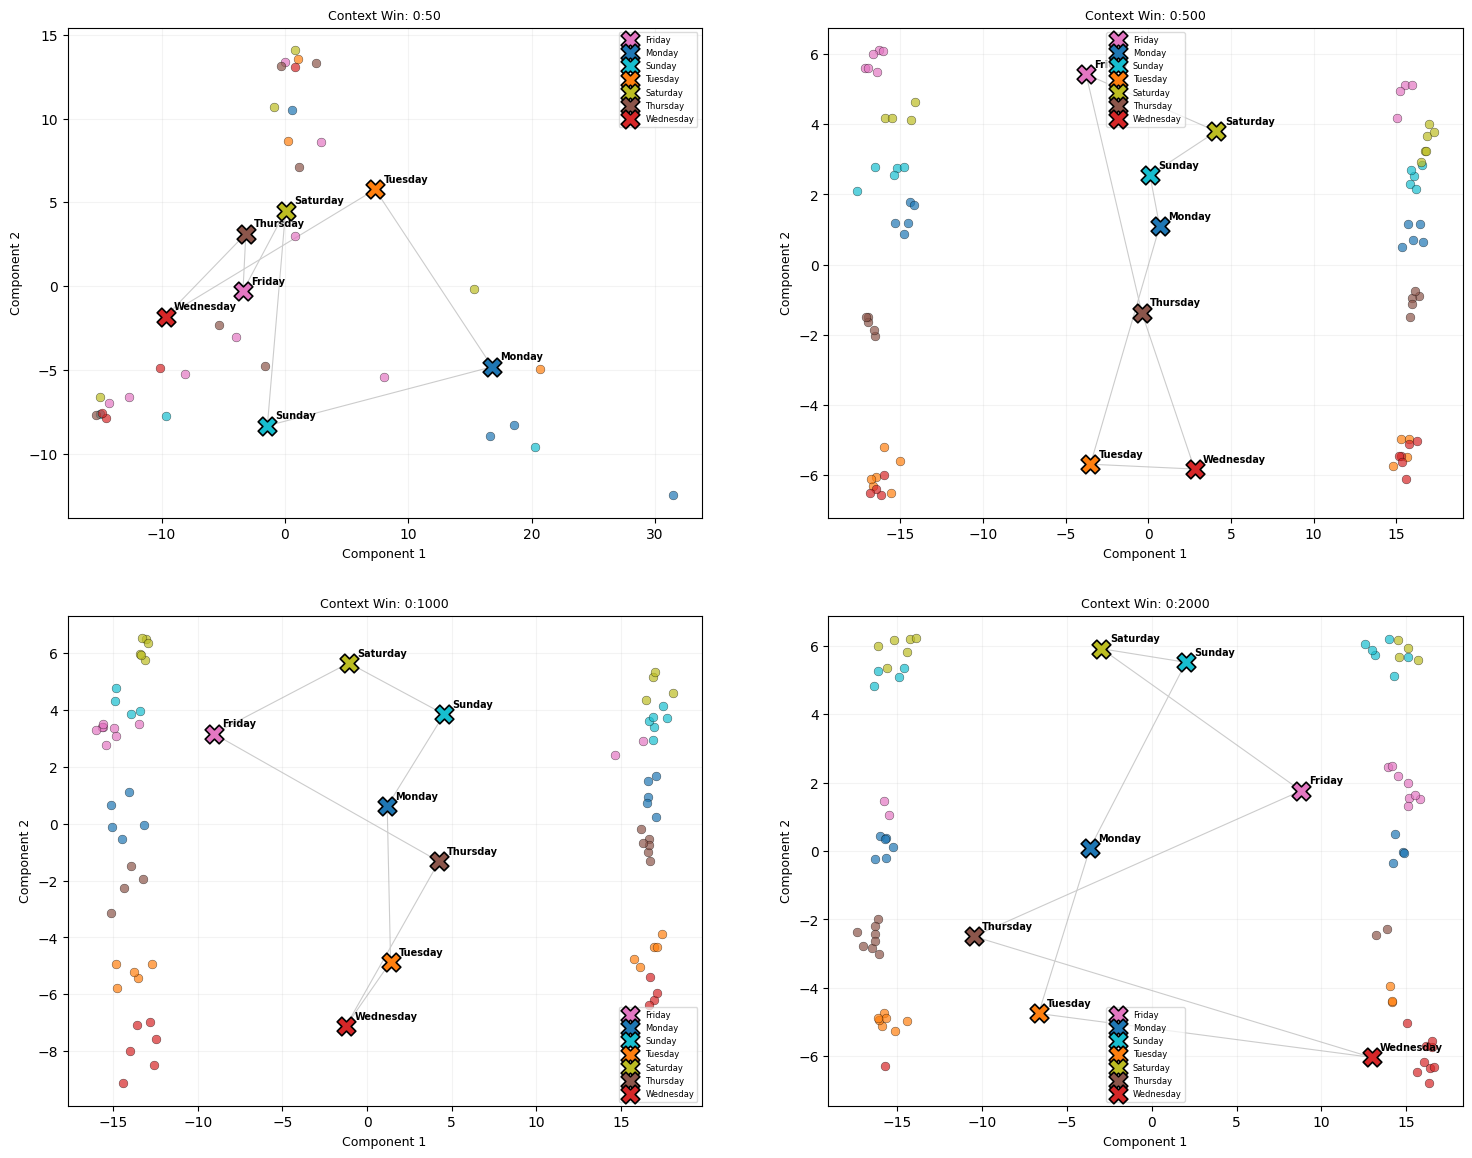

In [14]:
VOCAB_PATH  = Path("../data/days_tkid_map.txt")
STRUCT_PATH = Path("../data/one_random_walk/circle_days/circle_structure.txt")
EMB_DIR     = Path("../embeddings/numbers/circle_days")

hp_circle_das = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

ctx = 2000
CTX_LENS = [50,500, 1000, 2000]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_circle_days_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_circle_das.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    reducer = PCA(n_components=2, random_state=42)
    pca_result = reducer.fit_transform(filtered_embs)
    hp_circle_das.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

  [] Warning: token 'Saturday' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token 'Thursday' has only 6 occurrences in [0:50] (requested 10)
  [] Warning: token 'Wednesday' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token 'Friday' has only 8 occurrences in [0:50] (requested 10)
  [] Warning: token 'Monday' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token 'Sunday' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token 'Tuesday' has only 3 occurrences in [0:50] (requested 10)


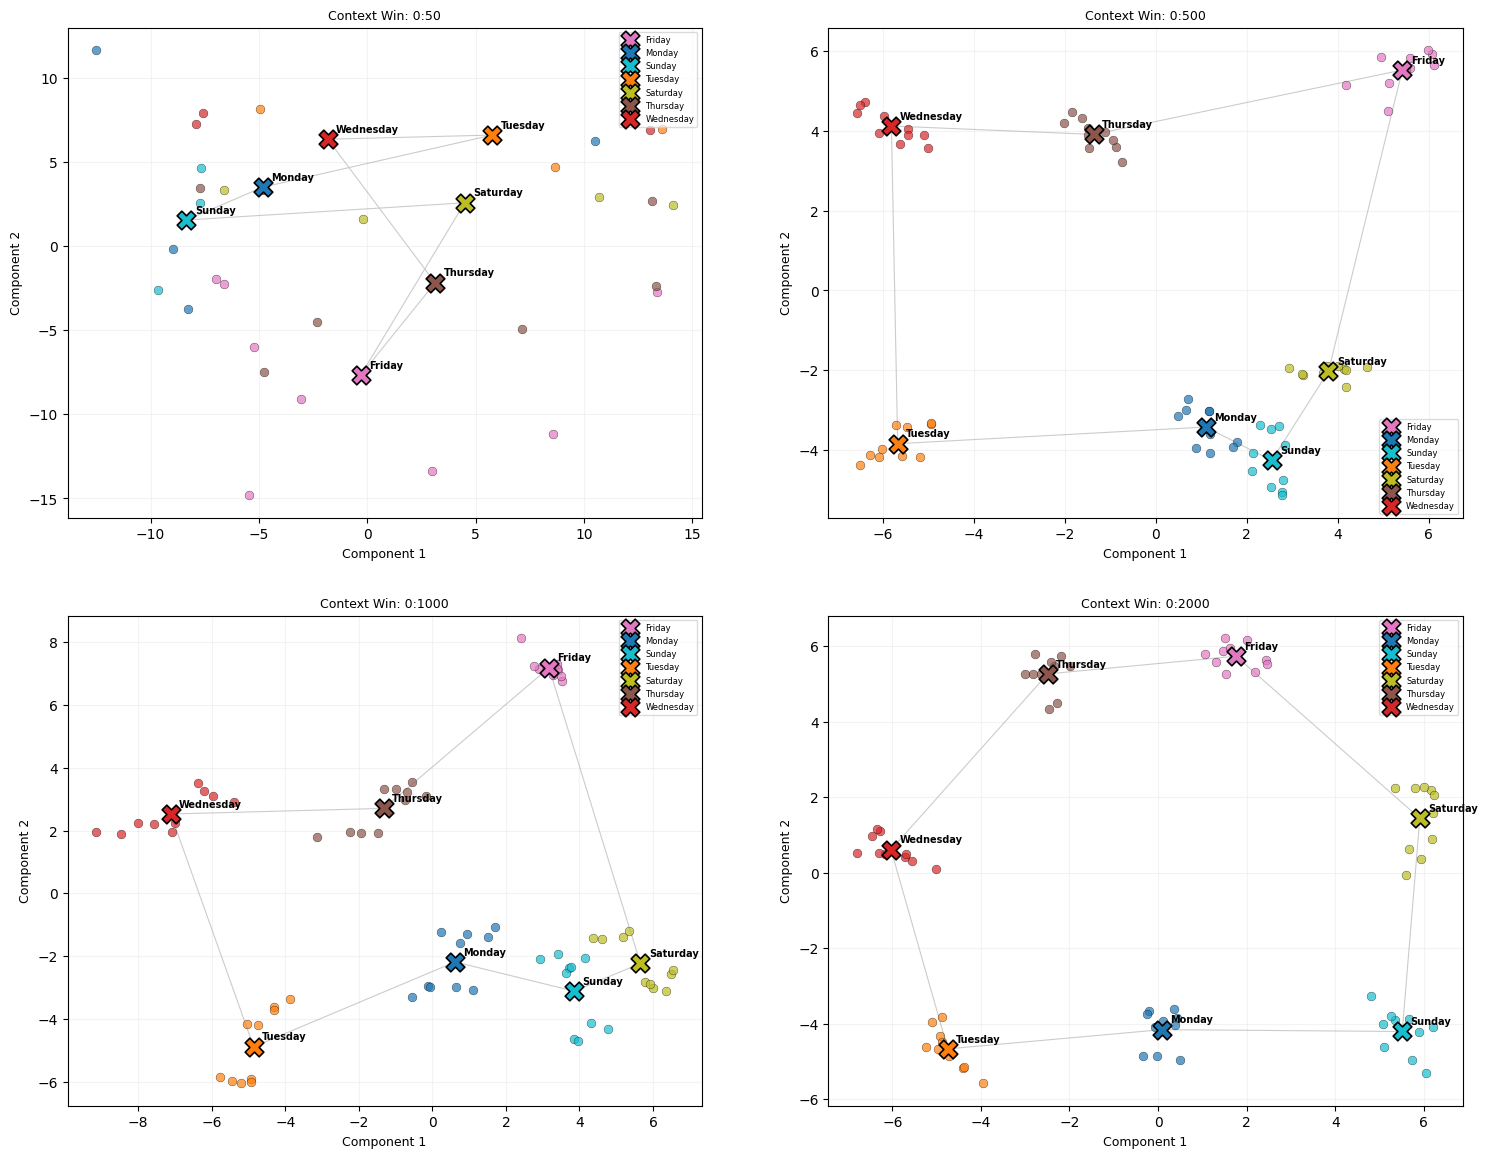

In [15]:
VOCAB_PATH  = Path("../data/days_tkid_map.txt")
STRUCT_PATH = Path("../data/one_random_walk/circle_days/circle_structure.txt")
EMB_DIR     = Path("../embeddings/numbers/circle_days")

hp_circle_das = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

ctx = 2000
CTX_LENS = [50,500, 1000, 2000]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_circle_days_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_circle_das.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    reducer = PCA(n_components=3, random_state=42)
    pca_result = reducer.fit_transform(filtered_embs)[:,1:3]
    hp_circle_das.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

# BACKUP

## Exp 3.1: Numbers Tree - leaves only (ordered)

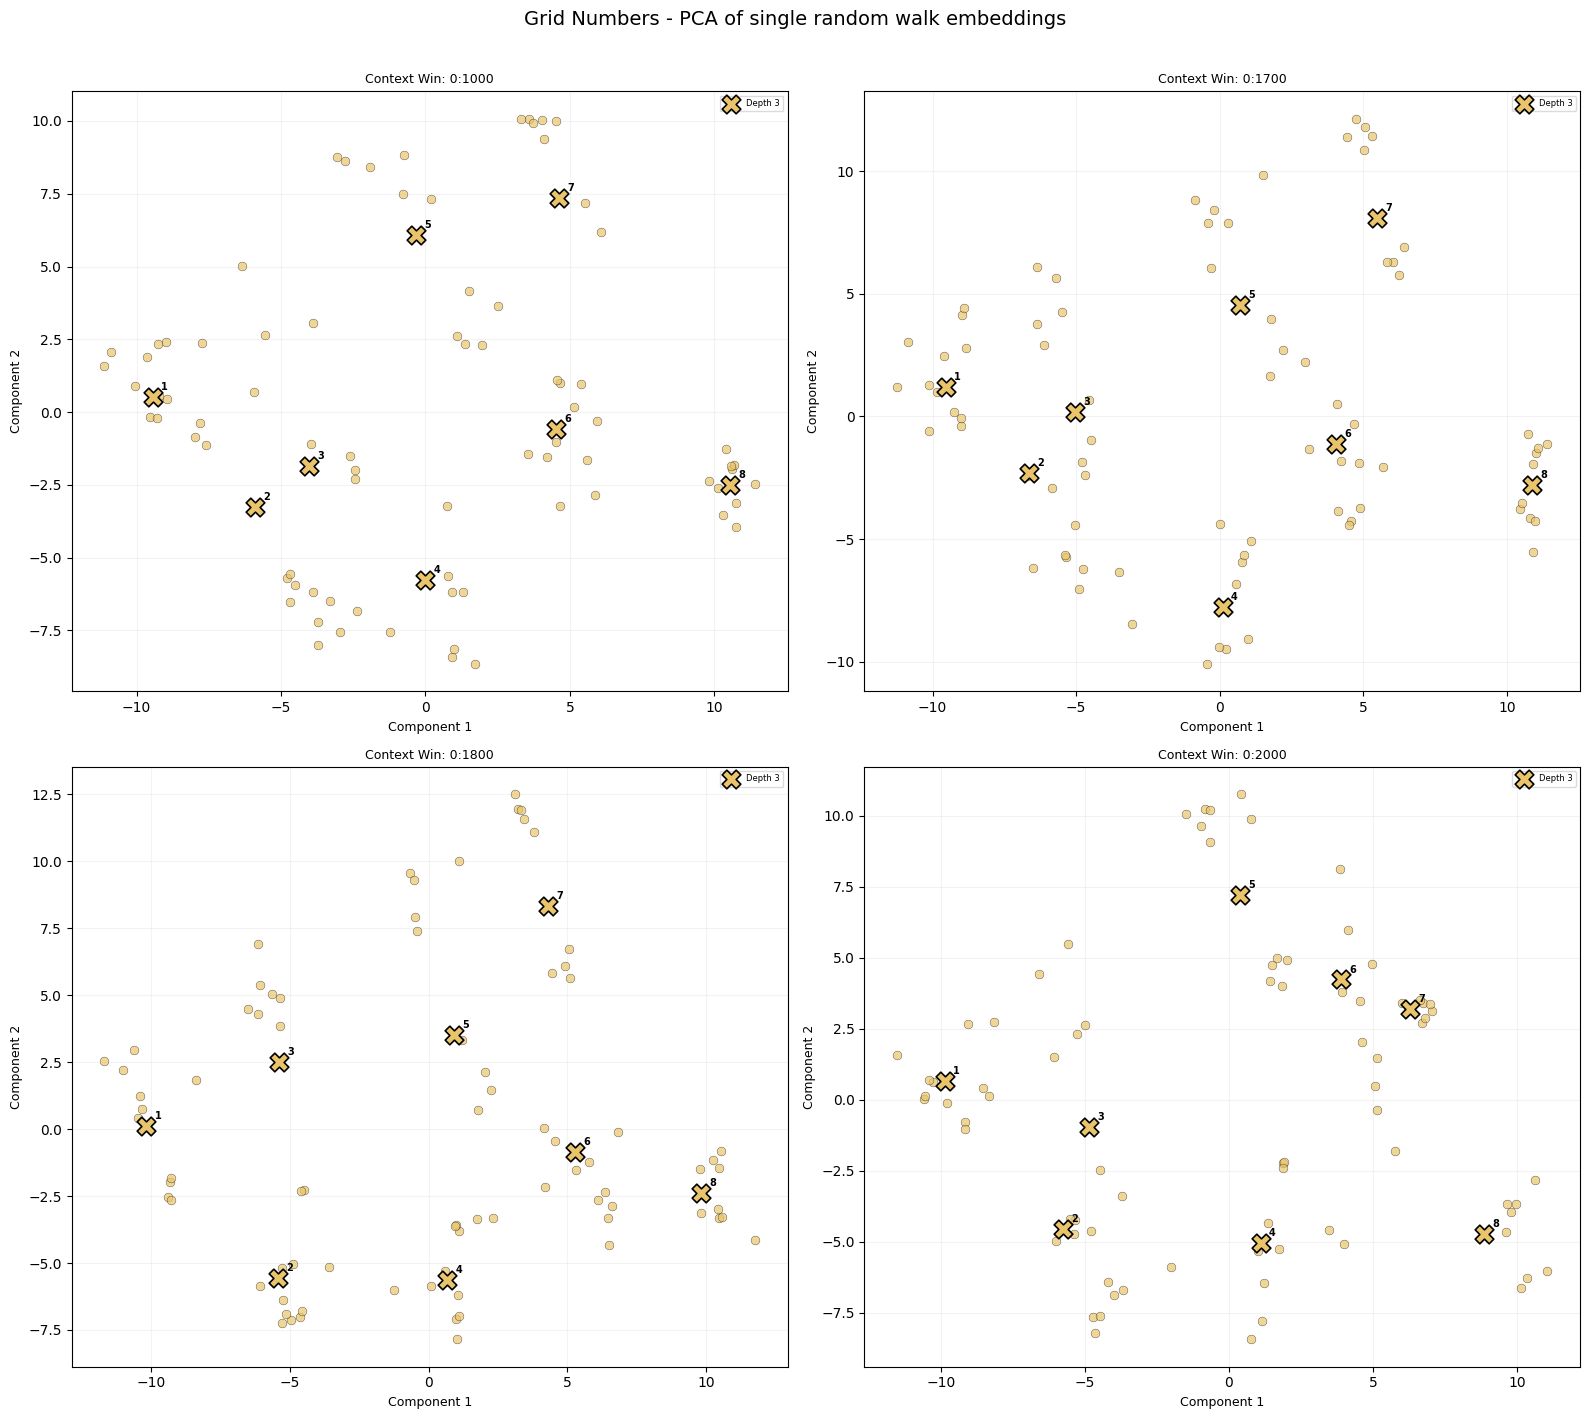

In [ ]:
EMB_DIR     = Path("../embeddings/numbers/only_leaves_ordered_tree")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/only_leaves_ordered_tree/tree_structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [  1000, 1700, 1800, 2000]


for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_tree_only_leaves_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(filtered_embs)

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle("Grid Numbers - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

Processing context length: 1000
Processing context length: 1700
Processing context length: 1800
Processing context length: 2000


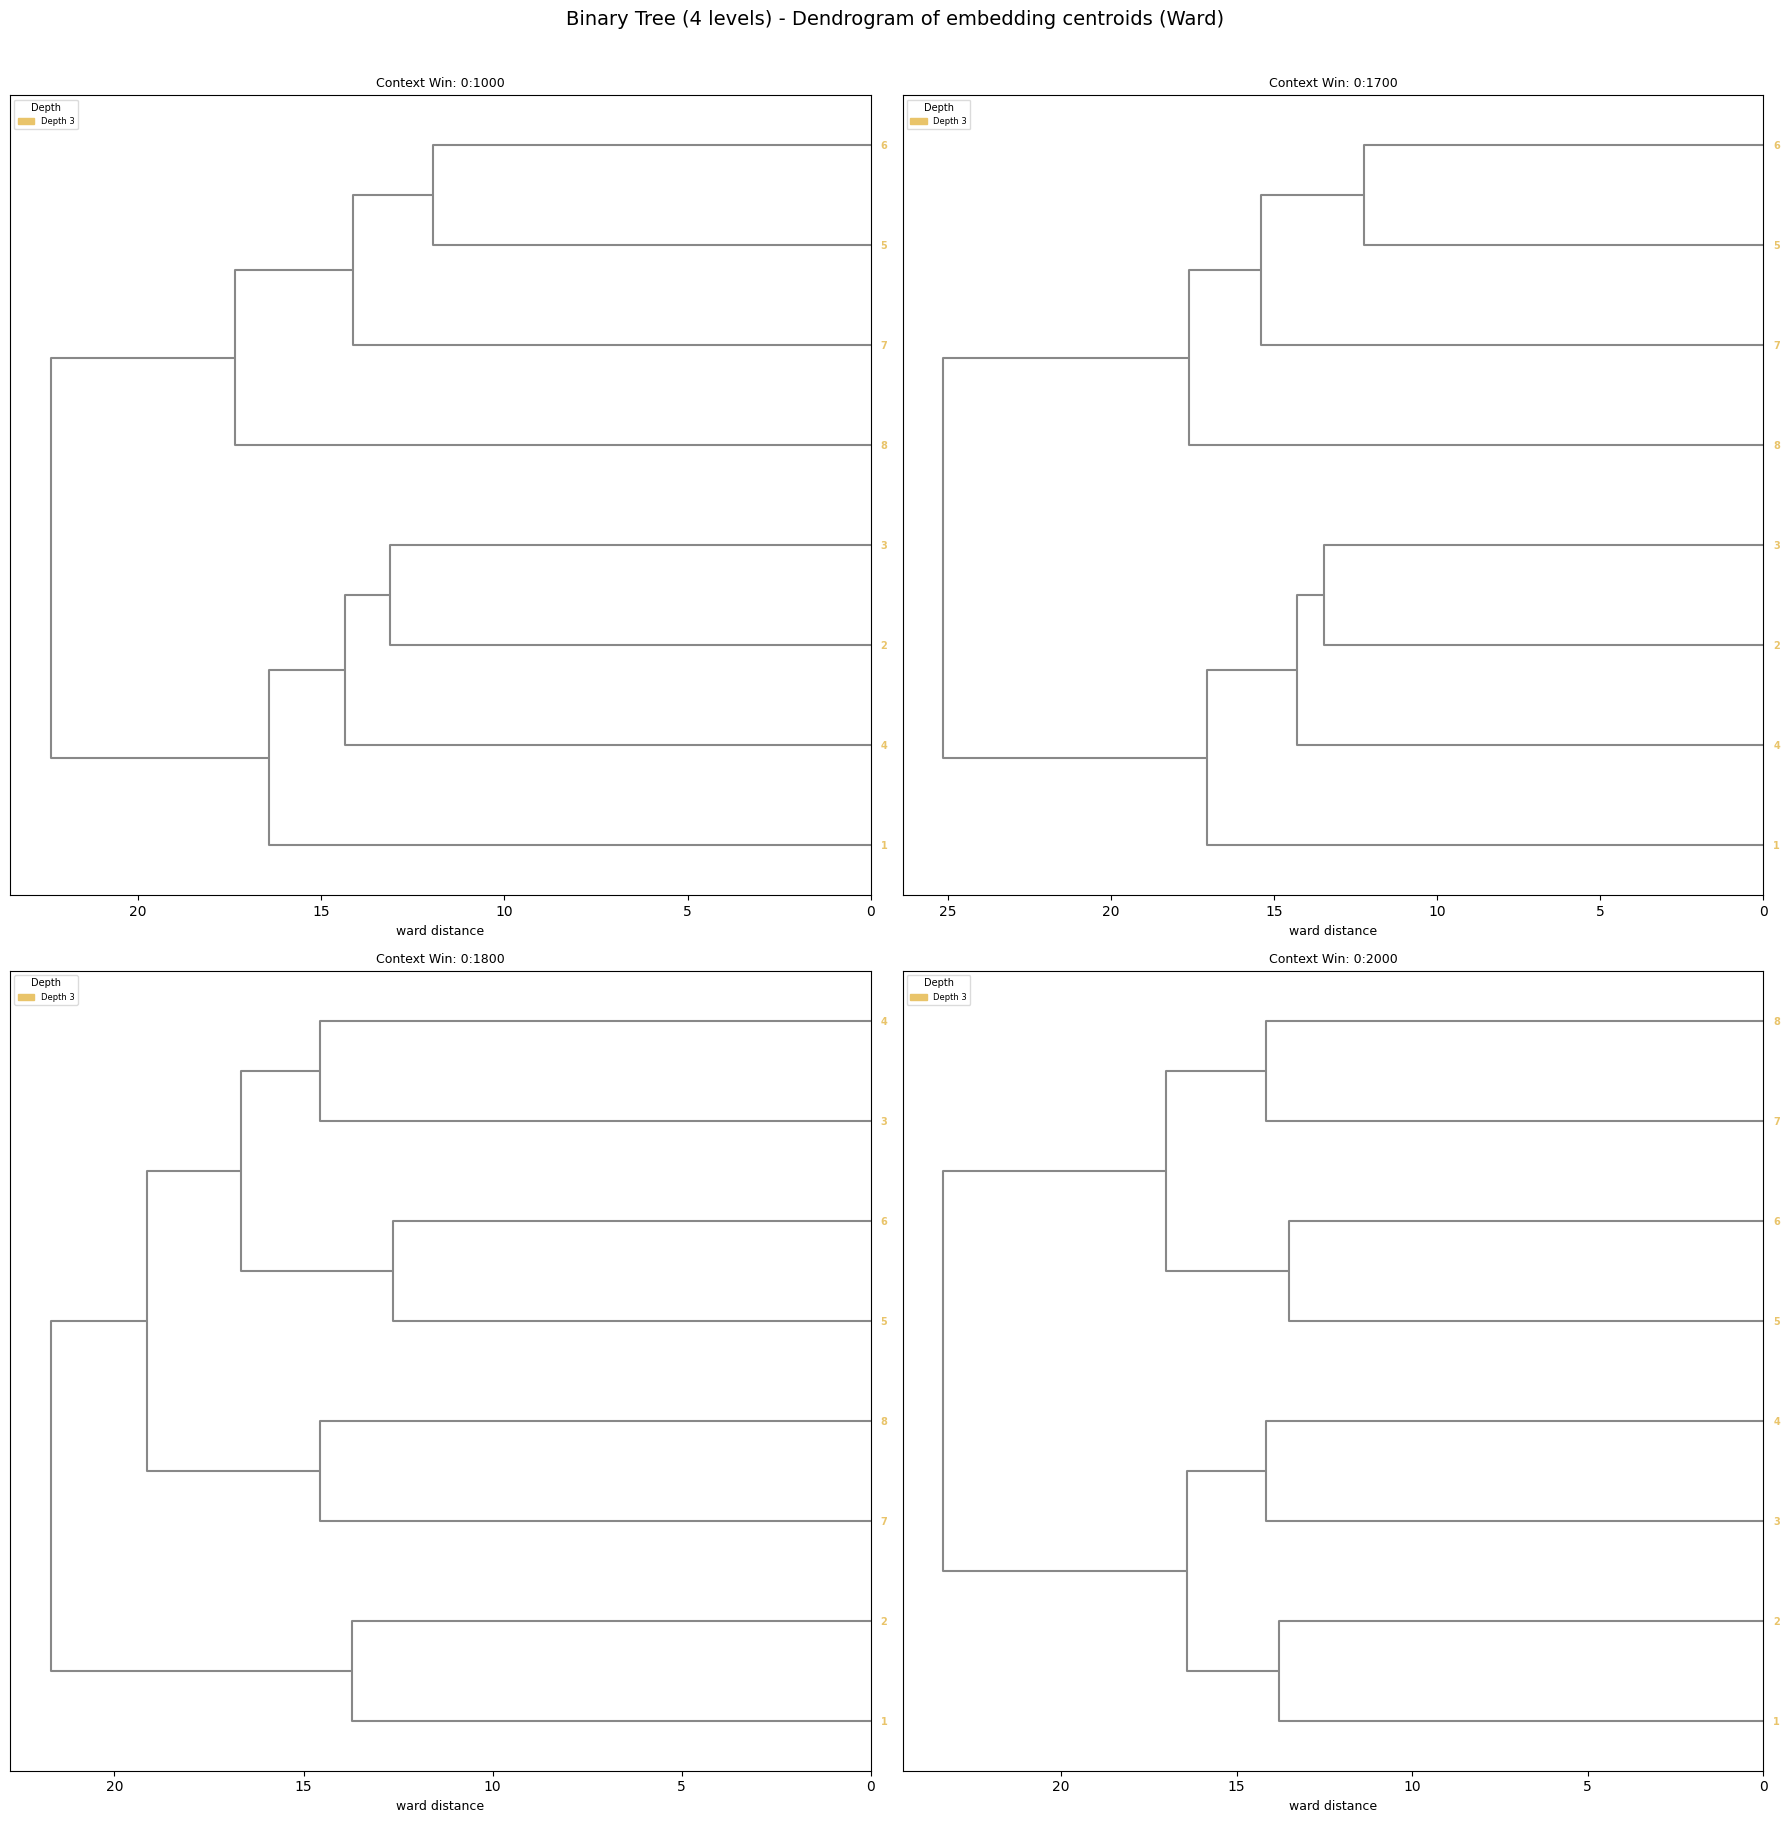

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

layer = 3 # quale livello dell'albero dendrogrammo

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

for ax, win in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {win}")
    pt_path = EMB_DIR / f"reprs_tree_only_leaves_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    mask_layer_l = np.isin(ids_np, ids_layer_l)

    emb_np = emb_np[mask_layer_l]
    ids_np = ids_np[mask_layer_l]

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, k=10, t_end=win)

    centroids_id, centroids_emb = centroids_by_token(filtered_ids, filtered_embs)

    hp_tree.plot_dendrogram_on_points(ax, centroids_id, centroids_emb, title=f"Context Win: 0:{win}", method="ward", max_leaves=50)

fig.suptitle("Binary Tree (4 levels) - Dendrogram of embedding centroids (Ward)",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Exp 3.2: Numbers Grid (shuffled) - VALUTARE CONTESTO PIÙ LUNGO

  [] Warning: token '15' has only 2 occurrences in [0:250] (requested 3)
  [] Warning: token '4' has only 2 occurrences in [0:250] (requested 3)


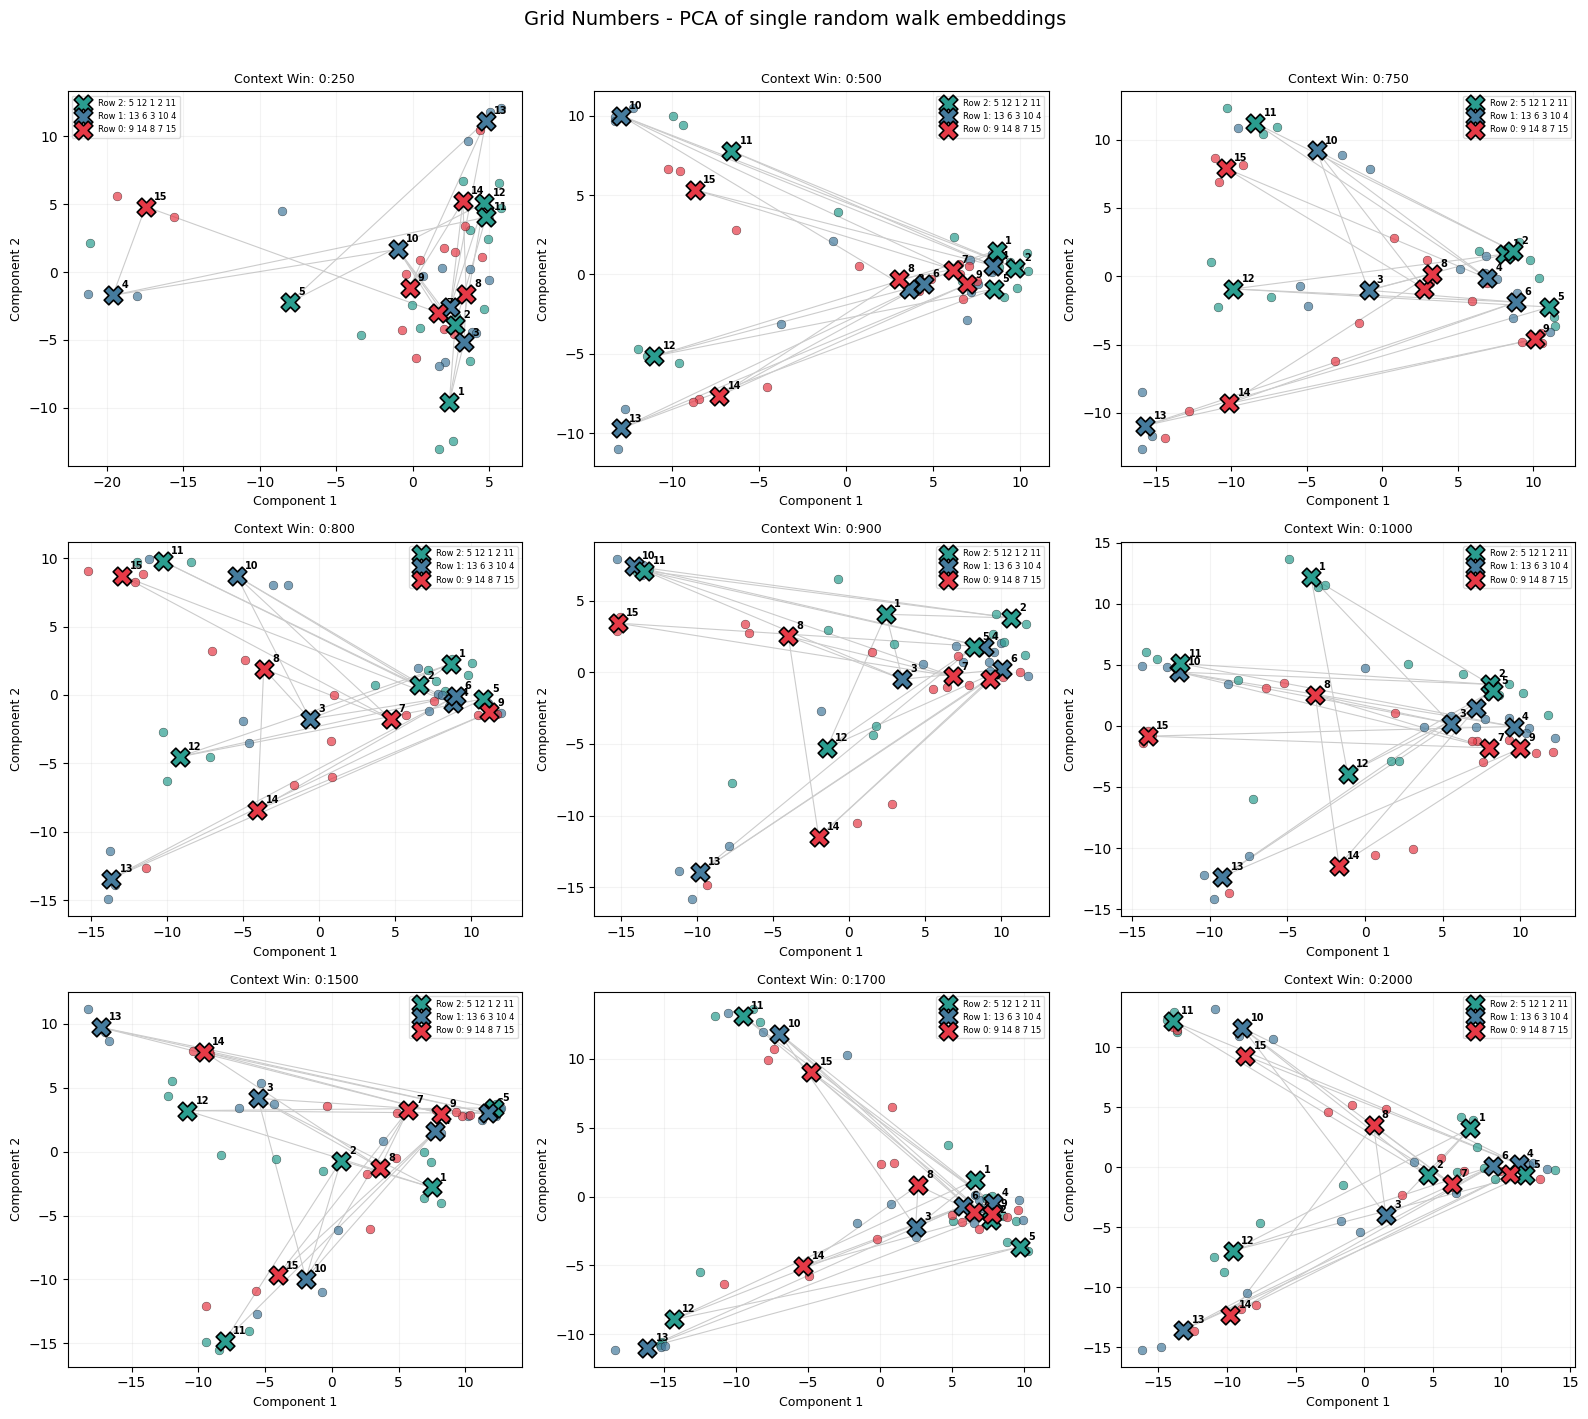

In [ ]:
EMB_DIR     = Path("../embeddings/numbers/shuffled_grid_numbers")
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/shuffled_grid_numbers/grid_structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
ctx = 2000
CTX_LENS = [250,500, 750, 800, 900, 1000, 1500, 1700, 2000]


for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_grid_numbers_shuffled_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=3, t_start=0, t_end=win_len)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(filtered_embs)

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle("Grid Numbers - PCA of single random walk embeddings",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Exp 5.2: Numbers Circle (shuffled) - BUTTARE

  [] Warning: token '15' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '11' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '12' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '14' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '1' has only 2 occurrences in [0:50] (requested 10)
  [] Warning: token '2' has only 2 occurrences in [0:50] (requested 10)
  [] Warning: token '3' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token '4' has only 2 occurrences in [0:50] (requested 10)
  [] Warning: token '6' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '7' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '9' has only 1 occurrences in [0:50] (requested 10)
  [] Warning: token '10' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token '15' has only 9 occurrences in [0:500] (requested 10)


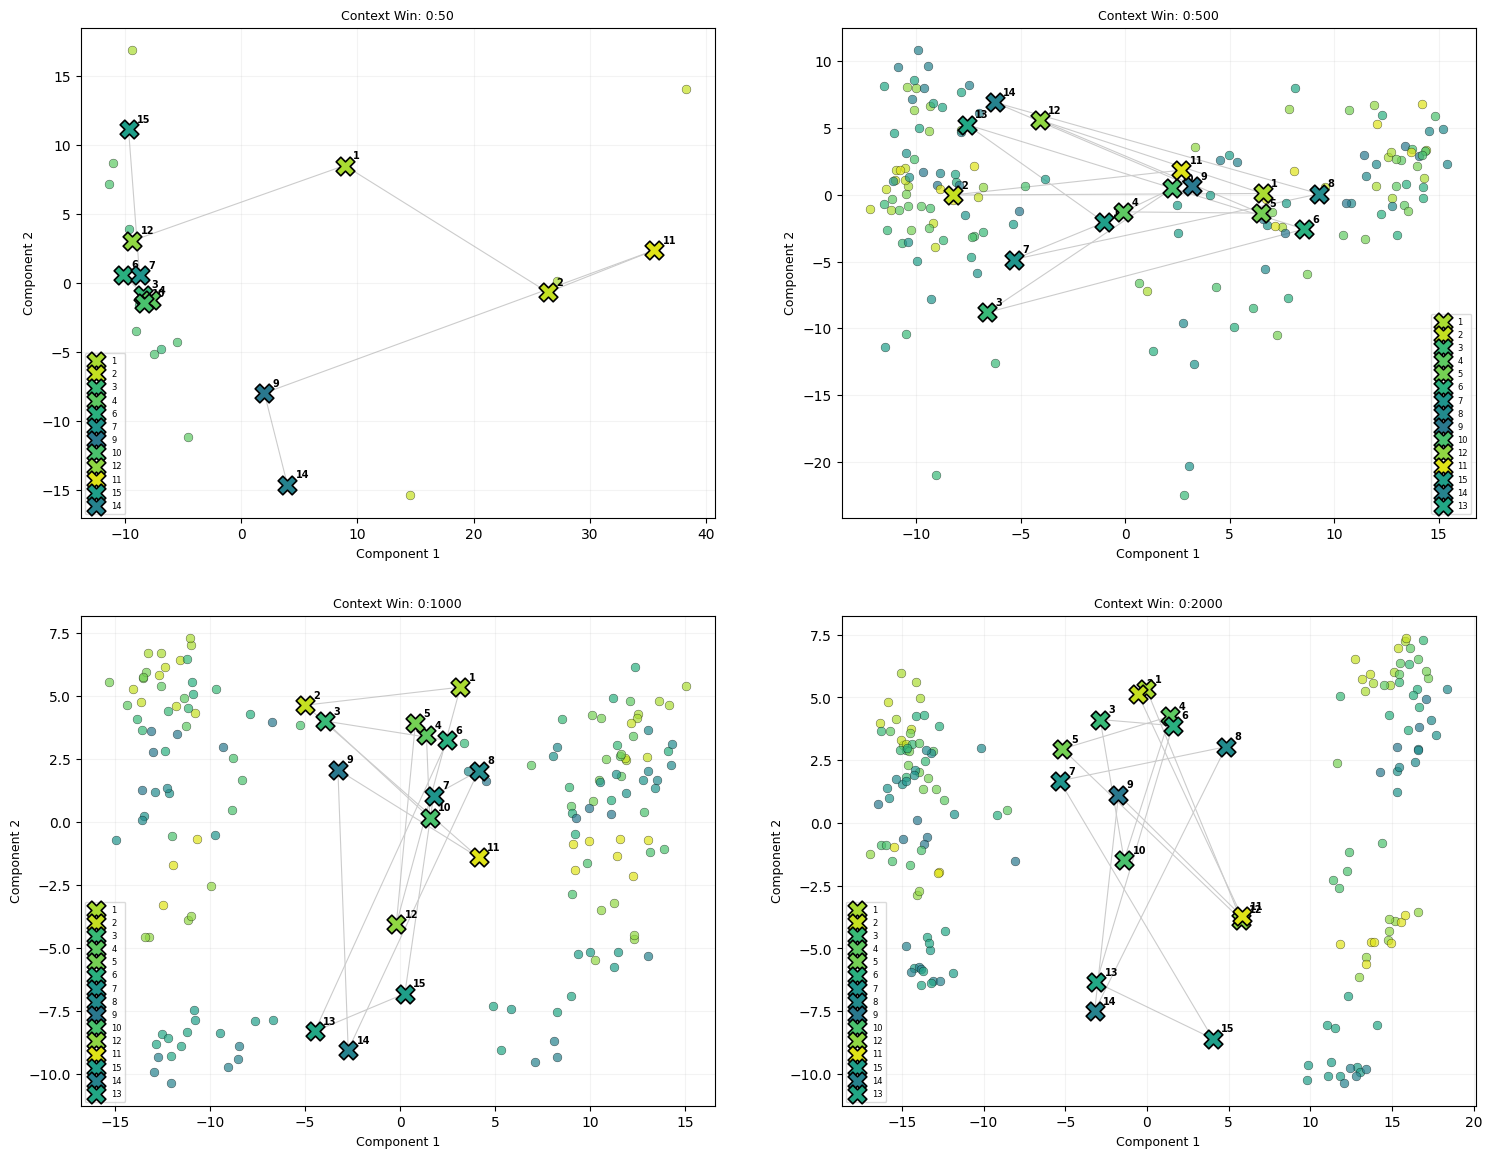

In [27]:
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/shuffled_circle_numbers/circle_structure.txt")
EMB_DIR     = Path("../embeddings/numbers/shuffled_circle_numbers")

hp_circle_num = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

ctx = 2000
CTX_LENS = [50,500, 1000, 2000]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_circle_numbers_shuffled_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_circle_num.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    reducer = PCA(n_components=2, random_state=42)
    pca_result = reducer.fit_transform(filtered_embs)
    hp_circle_num.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

  [] Warning: token '15' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token '11' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token '12' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token '14' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token '1' has only 2 occurrences in [0:50] (requested 5)
  [] Warning: token '2' has only 2 occurrences in [0:50] (requested 5)
  [] Warning: token '3' has only 3 occurrences in [0:50] (requested 5)
  [] Warning: token '4' has only 2 occurrences in [0:50] (requested 5)
  [] Warning: token '6' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token '7' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token '9' has only 1 occurrences in [0:50] (requested 5)
  [] Warning: token '10' has only 4 occurrences in [0:50] (requested 5)
  [] Warning: token '13' has only 4 occurrences in [0:250] (requested 5)


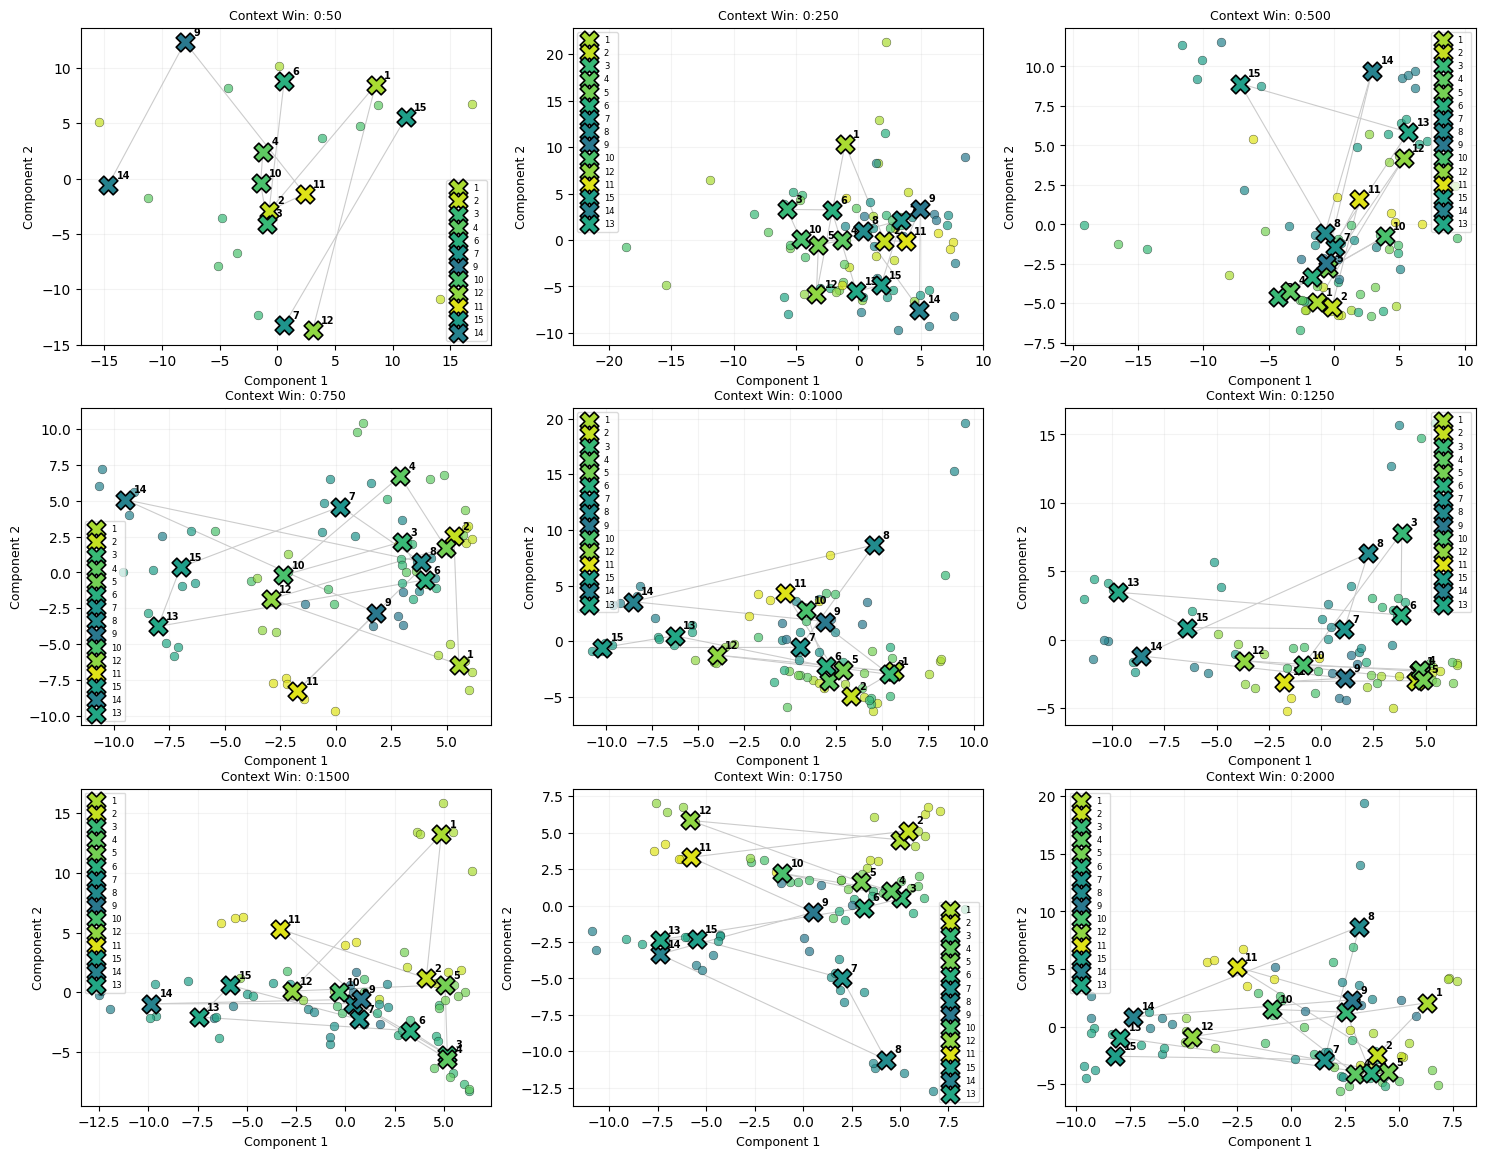

In [14]:
VOCAB_PATH  = Path("../data/number_ids.txt")
STRUCT_PATH = Path("../data/one_random_walk/shuffled_circle_numbers/circle_structure.txt")
EMB_DIR     = Path("../embeddings/numbers/shuffled_circle_numbers")

hp_circle_num = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

ctx = 2000
CTX_LENS = [50,250,500, 750, 1000, 1250, 1500, 1750, 2000]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_circle_numbers_shuffled_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_circle_num.id_to_word, 
                                                     k=5, t_start=0, t_end=win_len)
    reducer = PCA(n_components=3, random_state=42)
    pca_result = reducer.fit_transform(filtered_embs)[:,1:3]
    hp_circle_num.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

## Days Circle (shuffled) - VALUTARE CONTESTO PIÙ LUNGO

vedere se si riproduce il risultato del paper in pc più alte

  [] Warning: token 'Saturday' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token 'Thursday' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token 'Wednesday' has only 6 occurrences in [0:50] (requested 10)
  [] Warning: token 'Friday' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token 'Monday' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token 'Sunday' has only 8 occurrences in [0:50] (requested 10)
  [] Warning: token 'Tuesday' has only 4 occurrences in [0:50] (requested 10)


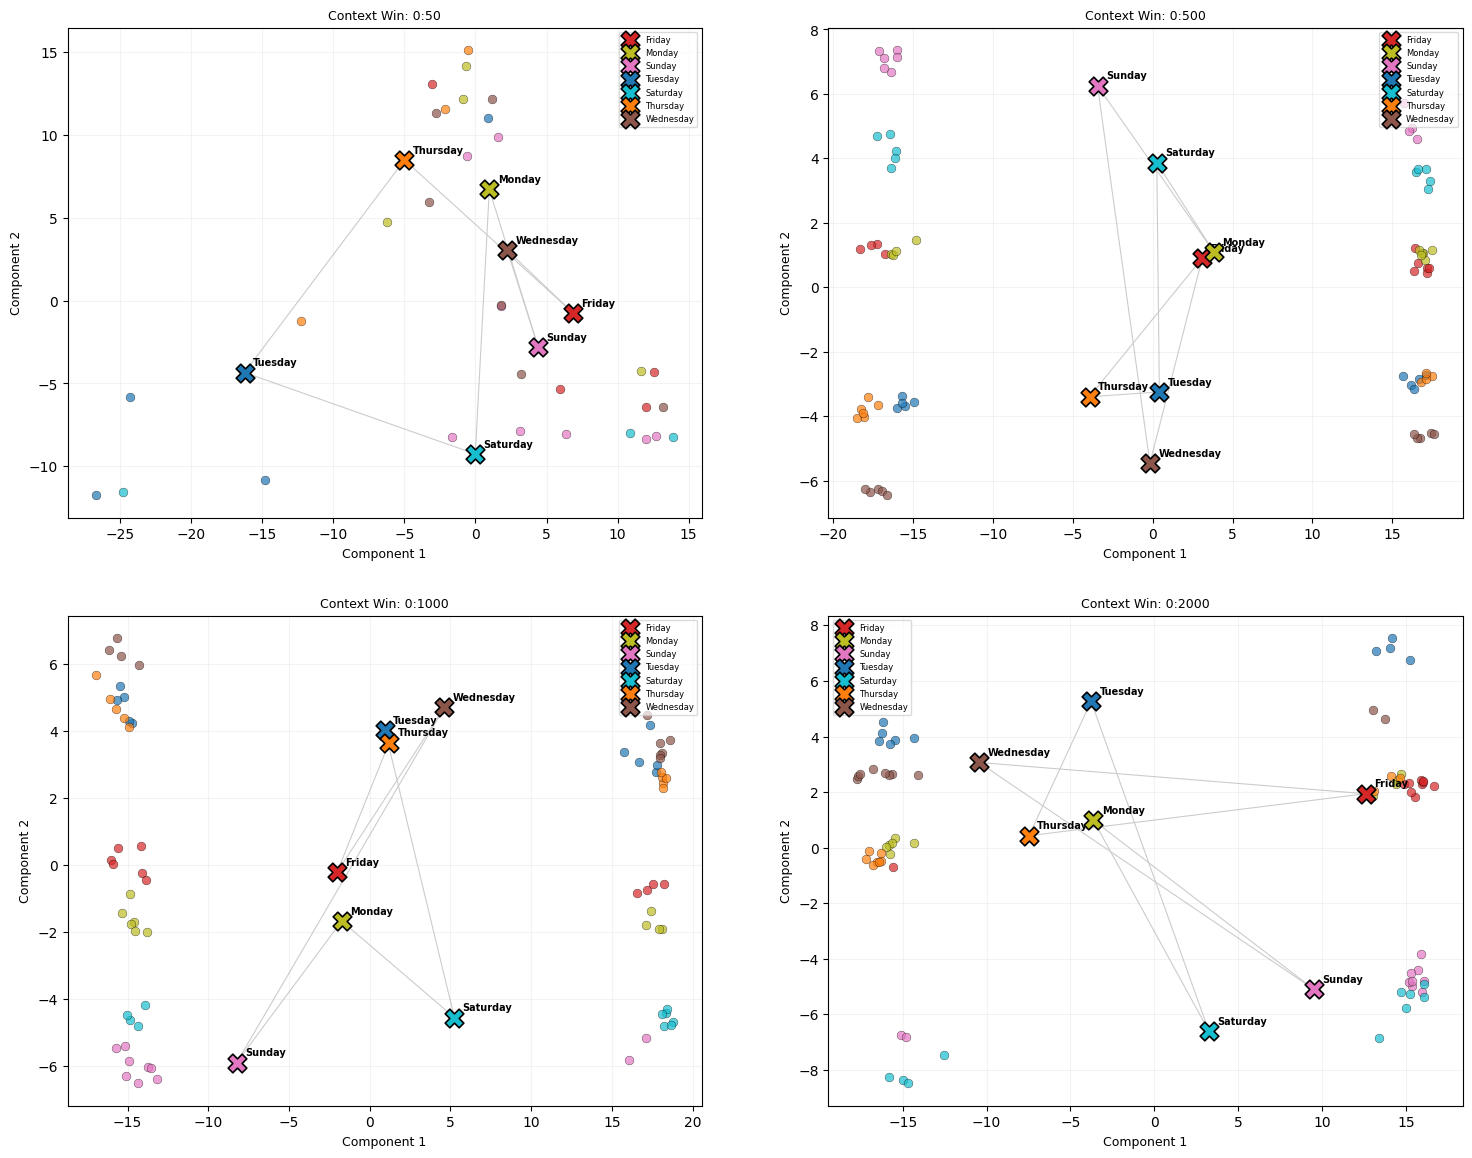

In [30]:
VOCAB_PATH  = Path("../data/days_tkid_map.txt")
STRUCT_PATH = Path("../data/one_random_walk/shuffled_circle_days/circle_structure.txt")
EMB_DIR     = Path("../embeddings/numbers/shuffled_circle_days")

hp_circle_das = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

ctx = 2000
CTX_LENS = [50,500, 1000, 2000]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_circle_days_shuffled_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_circle_das.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    reducer = PCA(n_components=2, random_state=42)
    pca_result = reducer.fit_transform(filtered_embs)
    hp_circle_das.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

  [] Warning: token 'Saturday' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token 'Thursday' has only 3 occurrences in [0:50] (requested 10)
  [] Warning: token 'Wednesday' has only 6 occurrences in [0:50] (requested 10)
  [] Warning: token 'Friday' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token 'Monday' has only 4 occurrences in [0:50] (requested 10)
  [] Warning: token 'Sunday' has only 8 occurrences in [0:50] (requested 10)
  [] Warning: token 'Tuesday' has only 4 occurrences in [0:50] (requested 10)


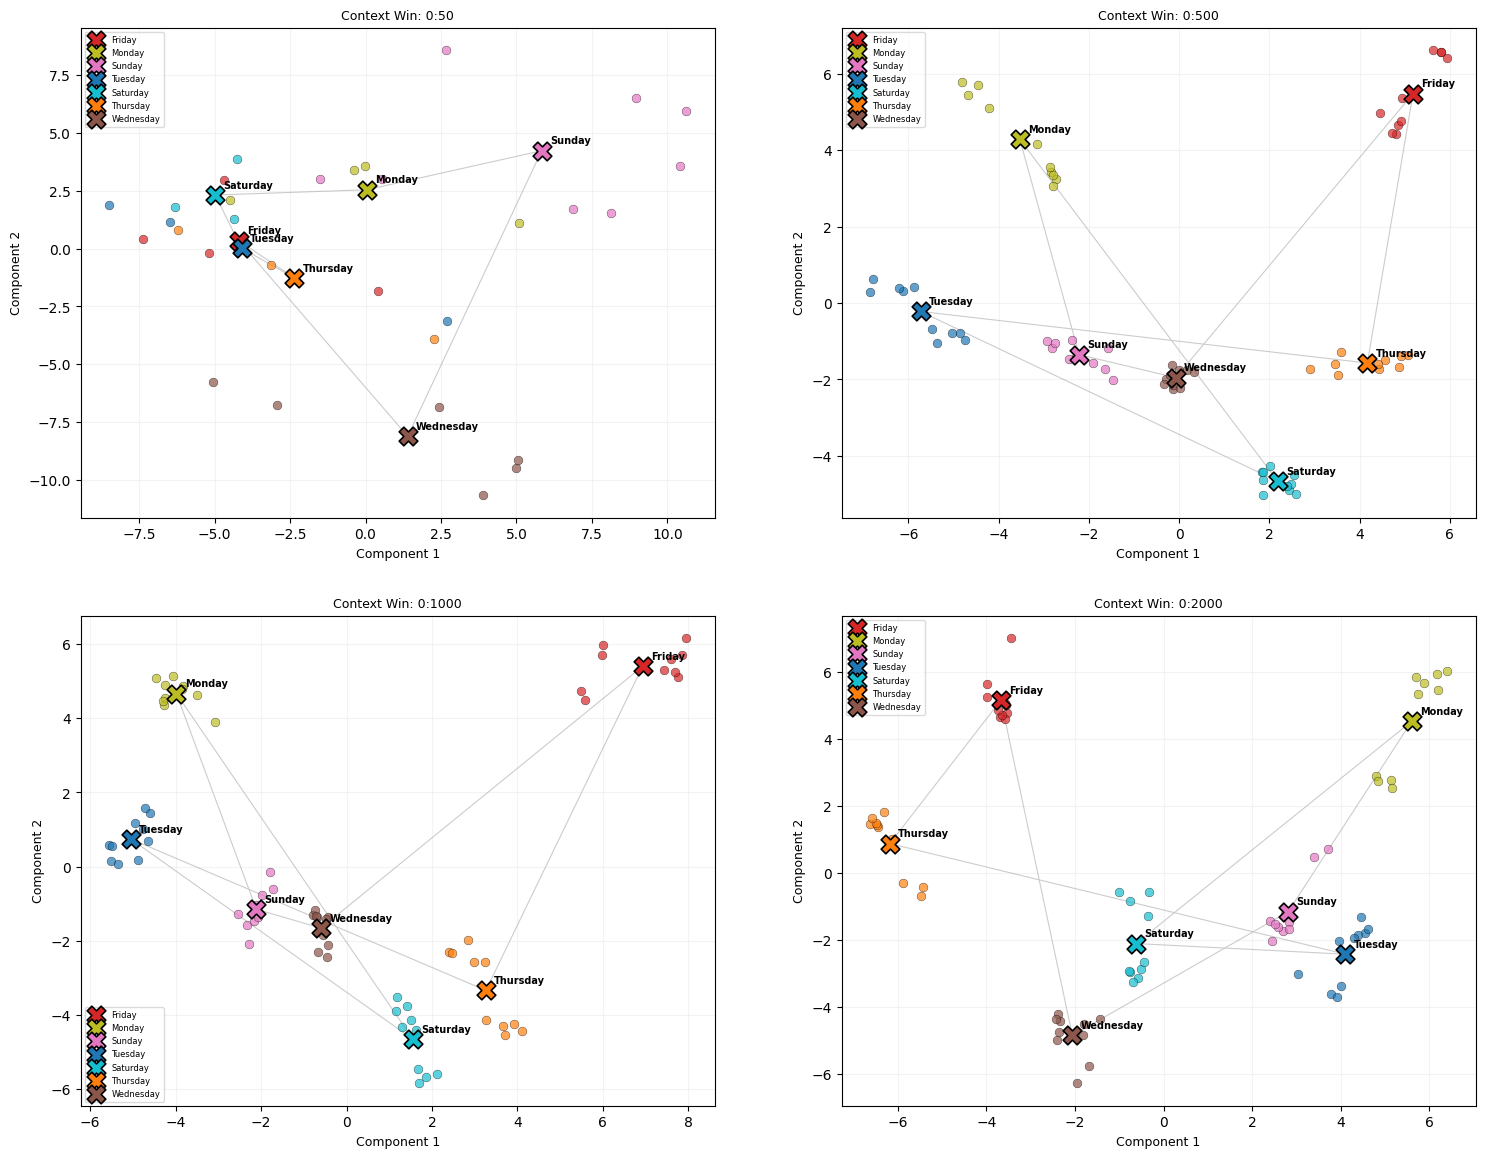

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

ctx = 2000
CTX_LENS = [50,500, 1000, 2000]

for ax, win_len in zip(axes.flat, CTX_LENS):
    pt_path = EMB_DIR / f"reprs_circle_days_shuffled_one_rw_{ctx}_line000000_layer31.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)
    

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_circle_das.id_to_word, 
                                                     k=10, t_start=0, t_end=win_len)
    reducer = PCA(n_components=4, random_state=42)
    pca_result = reducer.fit_transform(filtered_embs)[:,2:4]
    hp_circle_das.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)